# Predictive Modeling with Linear Regression Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.

### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.

### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [93]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [94]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.26.4 pandas==1.5.3 -q --user
!pip install --upgrade pip

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [95]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

## Loading the dataset

In [96]:
device_data = pd.read_csv("used_device_data.csv")
device_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

* intergers: release year, days_used
* strings: brand_name, os, 4g, 5g
* floats: screen_size, main_camera_mp, selfie_camera_mp, int_memory, ram, battery, weight, normalized_used_price, normalized_new_price

## Data Overview

- Observations
- Sanity checks

In [97]:
device_data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [98]:
device_data.tail()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994


In [99]:
device_data.shape

(3454, 15)

3454 > 30, data is normalized

In [100]:
device_data.describe().astype(int)

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454,3275,3452,3450,3450,3448,3447,3454,3454,3454,3454
mean,13,9,6,54,4,3133,182,2015,674,4,5
std,3,4,6,84,1,1299,88,2,248,0,0
min,5,0,0,0,0,500,69,2013,91,1,2
25%,12,5,2,16,4,2100,142,2014,533,4,4
50%,12,8,5,32,4,3000,160,2015,690,4,5
75%,15,13,8,64,4,4000,185,2018,868,4,5
max,30,48,32,1024,12,9720,855,2020,1094,6,7


In [101]:
print('missing values: \n' + str(device_data.isna().sum()))       # missing values
print('duplicate rows: ' + str(device_data.duplicated().sum()))   # duplicate rows

missing values: 
brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64
duplicate rows: 0


theres missing values in the main_camera_mp, selfie_camera_mp, int_memory, ram, battery, and weight. the median of each will be taken and inserted in the blank entries

In [164]:
device_data = pd.read_csv("used_device_data.csv")  # refresh

main_camera_mp_total_count = len(device_data['main_camera_mp'])
main_camera_mp_missing_value = device_data['main_camera_mp'].isna().sum()  # or == "Not given"
main_camera_mp_percentage_missing = (main_camera_mp_missing_value / main_camera_mp_total_count) * 100

print(f"Total entries including missing values: {main_camera_mp_total_count}\n")
print(f"Missing values for main_camera_mp: {main_camera_mp_missing_value}")
print(f"Percentage missing for main_camera_mp: {main_camera_mp_percentage_missing:.1f}%\n")

selfie_camera_mp_total_count = len(device_data['selfie_camera_mp'])
selfie_camera_mp_missing_value = device_data['selfie_camera_mp'].isna().sum()  # or == "Not given"
selfie_camera_mp_percentage_missing = (selfie_camera_mp_missing_value / selfie_camera_mp_total_count) * 100

print(f"Missing values for selfie_camera_mp: {selfie_camera_mp_missing_value}")
print(f"Percentage missing for selfie_camera_mp: {selfie_camera_mp_percentage_missing:.1f}%\n")

int_memory_total_count = len(device_data['int_memory'])
int_memory_missing_value = device_data['int_memory'].isna().sum()  # or == "Not given"
int_memory_percentage_missing = (int_memory_missing_value / int_memory_total_count) * 100

print(f"Missing values for int_memory: {int_memory_missing_value}")
print(f"Percentage missing for int_memory: {int_memory_percentage_missing:.1f}%\n")

ram_total_count = len(device_data['ram'])
ram_missing_value = device_data['ram'].isna().sum()  # or == "Not given"
ram_percentage_missing = (ram_missing_value / ram_total_count) * 100

print(f"Missing values for ram: {ram_missing_value}")
print(f"Percentage missing for ram: {ram_percentage_missing:.1f}%\n")

battery_total_count = len(device_data['battery'])
battery_missing_value = device_data['battery'].isna().sum()  # or == "Not given"
battery_percentage_missing = (battery_missing_value / battery_total_count) * 100

print(f"Missing values for battery: {battery_missing_value}")
print(f"Percentage missing for battery: {battery_percentage_missing:.1f}%\n")

weight_total_count = len(device_data['weight'])
weight_missing_value = device_data['weight'].isna().sum()  # or == "Not given"
weight_percentage_missing = (weight_missing_value / weight_total_count) * 100

print(f"Missing values for weight: {weight_missing_value}")
print(f"Percentage missing for weight: {weight_percentage_missing:.1f}%\n")


Total entries including missing values: 3454

Missing values for main_camera_mp: 179
Percentage missing for main_camera_mp: 5.2%

Missing values for selfie_camera_mp: 2
Percentage missing for selfie_camera_mp: 0.1%

Missing values for int_memory: 4
Percentage missing for int_memory: 0.1%

Missing values for ram: 4
Percentage missing for ram: 0.1%

Missing values for battery: 6
Percentage missing for battery: 0.2%

Missing values for weight: 7
Percentage missing for weight: 0.2%



In [165]:
median_main_camera_mp = device_data['main_camera_mp'].median()
print(f"The median for main camera megapixels is: {median_main_camera_mp:.2f} MP")

median_selfie_camera_mp = device_data['selfie_camera_mp'].median()
print(f"The median for selfie camera megapixels is: {median_selfie_camera_mp:.2f} MP")

median_int_memory_gb = device_data['int_memory'].median()
print(f"The median for internal memory is: {median_int_memory_gb:.2f} GB")

median_ram = device_data['ram'].median()
print(f"The median for RAM is: {median_ram:.2f} GB")

median_battery = device_data['battery'].median()
print(f"The median for battery capacity is: {median_battery:.2f} mAh")

median_weight = device_data['weight'].median()
print(f"The median for weight is: {median_weight:.2f} g")

The median for main camera megapixels is: 8.00 MP
The median for selfie camera megapixels is: 5.00 MP
The median for internal memory is: 32.00 GB
The median for RAM is: 4.00 GB
The median for battery capacity is: 3000.00 mAh
The median for weight is: 160.00 g


In [166]:
# Replace missing values with their respective medians
device_data['main_camera_mp'].fillna(median_main_camera_mp, inplace=True)
device_data['selfie_camera_mp'].fillna(median_selfie_camera_mp, inplace=True)
device_data['int_memory'].fillna(median_int_memory_gb, inplace=True)
device_data['ram'].fillna(median_ram, inplace=True)
device_data['battery'].fillna(median_battery, inplace=True)
device_data['weight'].fillna(median_weight, inplace=True)

# Quick check WITH total counts
cols = ['main_camera_mp','selfie_camera_mp','int_memory','ram','battery','weight']
totals = {col: len(device_data[col]) for col in cols}
missing_after = device_data[cols].isna().sum()

print("After imputation:")
for col in cols:
    print(f"{col}: {missing_after[col]} missing / {totals[col]} total")


After imputation:
main_camera_mp: 0 missing / 3454 total
selfie_camera_mp: 0 missing / 3454 total
int_memory: 0 missing / 3454 total
ram: 0 missing / 3454 total
battery: 0 missing / 3454 total
weight: 0 missing / 3454 total


In [167]:
device_data.describe().astype(int) #new data with no missing values

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454,3454,3454,3454,3454,3454,3454,3454,3454,3454,3454
mean,13,9,6,54,4,3133,182,2015,674,4,5
std,3,4,6,84,1,1298,88,2,248,0,0
min,5,0,0,0,0,500,69,2013,91,1,2
25%,12,5,2,16,4,2100,142,2014,533,4,4
50%,12,8,5,32,4,3000,160,2015,690,4,5
75%,15,13,8,64,4,4000,185,2018,868,4,5
max,30,48,32,1024,12,9720,855,2020,1094,6,7


In [168]:
summary = pd.DataFrame({
    'min': device_data.min(numeric_only=True),
    'median': device_data.median(numeric_only=True),
    'max': device_data.max(numeric_only=True)
}).round(2)
print(summary)


                           min   median      max
screen_size               5.08    12.83    30.71
main_camera_mp            0.08     8.00    48.00
selfie_camera_mp          0.00     5.00    32.00
int_memory                0.01    32.00  1024.00
ram                       0.02     4.00    12.00
battery                 500.00  3000.00  9720.00
weight                   69.00   160.00   855.00
release_year           2013.00  2015.50  2020.00
days_used                91.00   690.50  1094.00
normalized_used_price     1.54     4.41     6.62
normalized_new_price      2.90     5.25     7.85


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [177]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=True, bins=None):
    """
    Boxplot and histogram combined for device_data screen_size analysis
    
    data: device_data dataframe (phones/tablets)
    feature: 'screen_size' column name
    figsize: size of figure (default (15,10))
    kde: whether to show density curve (default True for screen_size)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis shared among subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot (mean triangle)
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # histogram (kde recommended for screen_size)
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--", label="Mean"
    )  # mean line
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-", label="Median"
    )  # median line
    ax_hist2.legend()
    
    plt.suptitle(f'{feature.title()} Distribution (Phones/Tablets)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Usage for your project:
# histogram_boxplot(device_data, 'screen_size', kde=True)
# histogram_boxplot(large_screen, 'screen_size')  # >6in subset


In [178]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Labeled barplot for device_data categorical analysis (brand_name, os, device_type)
    
    data: device_data or large_screen dataframe (phones/tablets)
    feature: 'brand_name', 'os', or 'device_type' column
    perc: show percentages (default False=counts)
    n: top n categories (default None=all; use 10-15 for brand_name)
    """
    total = len(data[feature])  # total devices
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(max(count, 10) + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=12)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="husl",  # Better for brand_name variety
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = f"{int(p.get_height())}"

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=11,
            xytext=(0, 5),
            textcoords="offset points",
            fontweight="bold"
        )  # Clear labels for counts/%

    plt.title(f'{feature.replace("_", " ").title()} Distribution (N={total:,})', fontsize=14)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Usage examples:
# labeled_barplot(device_data, 'brand_name', n=15)  # Top brands
# labeled_barplot(large_screen, 'os', perc=True)  # >6in OS shares
# labeled_barplot(device_data, 'device_type')  # Phones vs Tablets


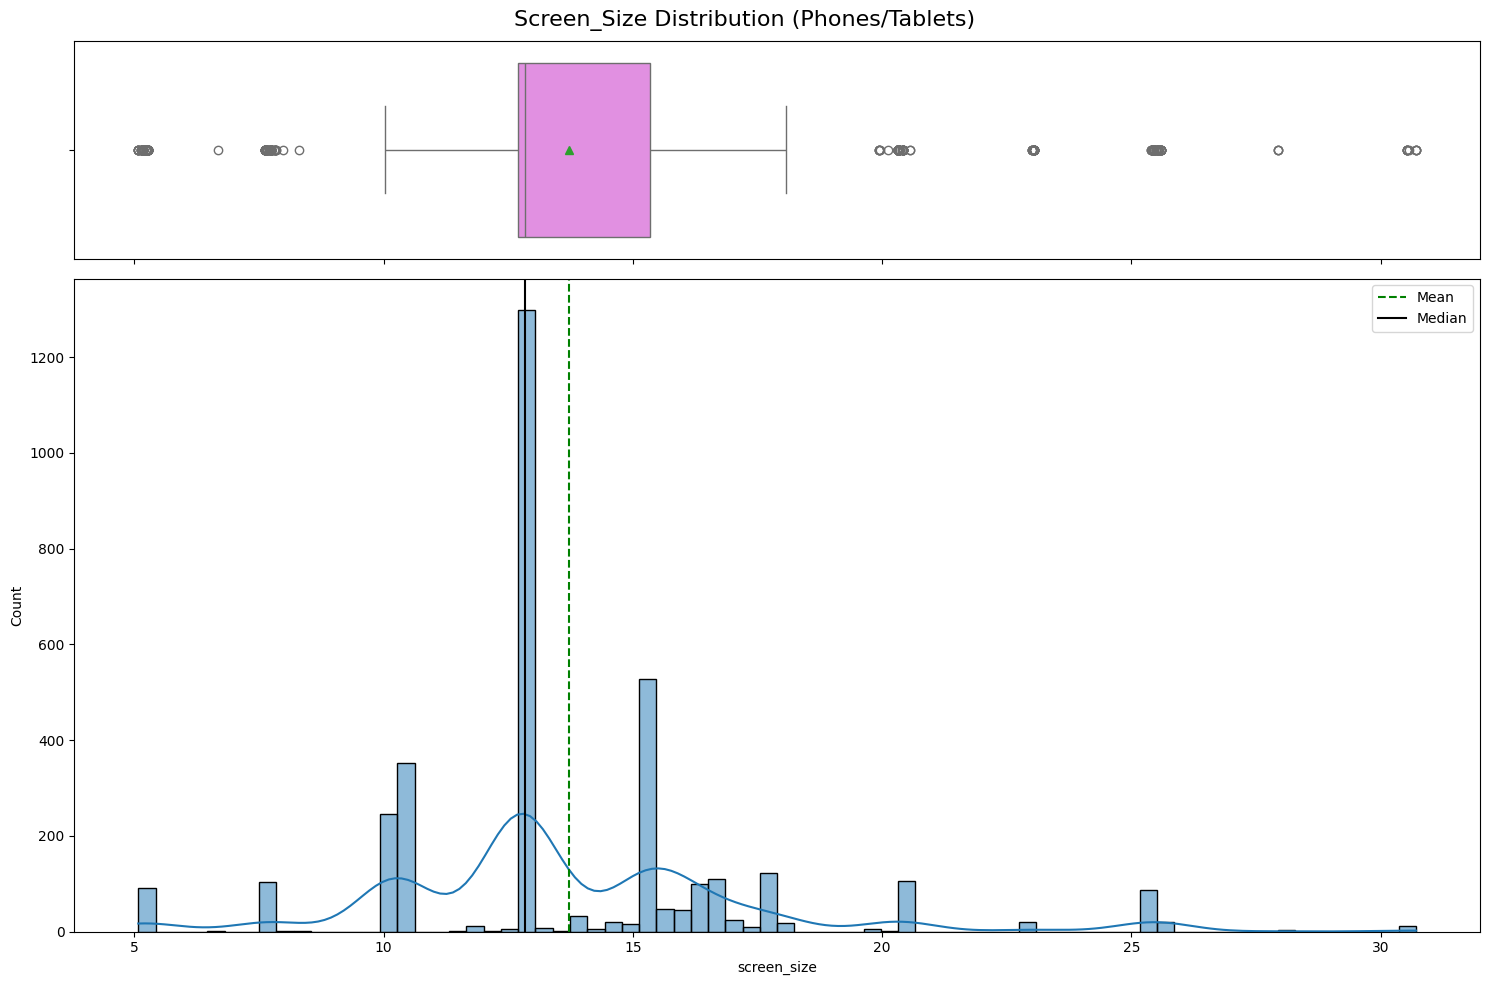

In [179]:
histogram_boxplot(device_data, "screen_size")

13 inch phones dominate

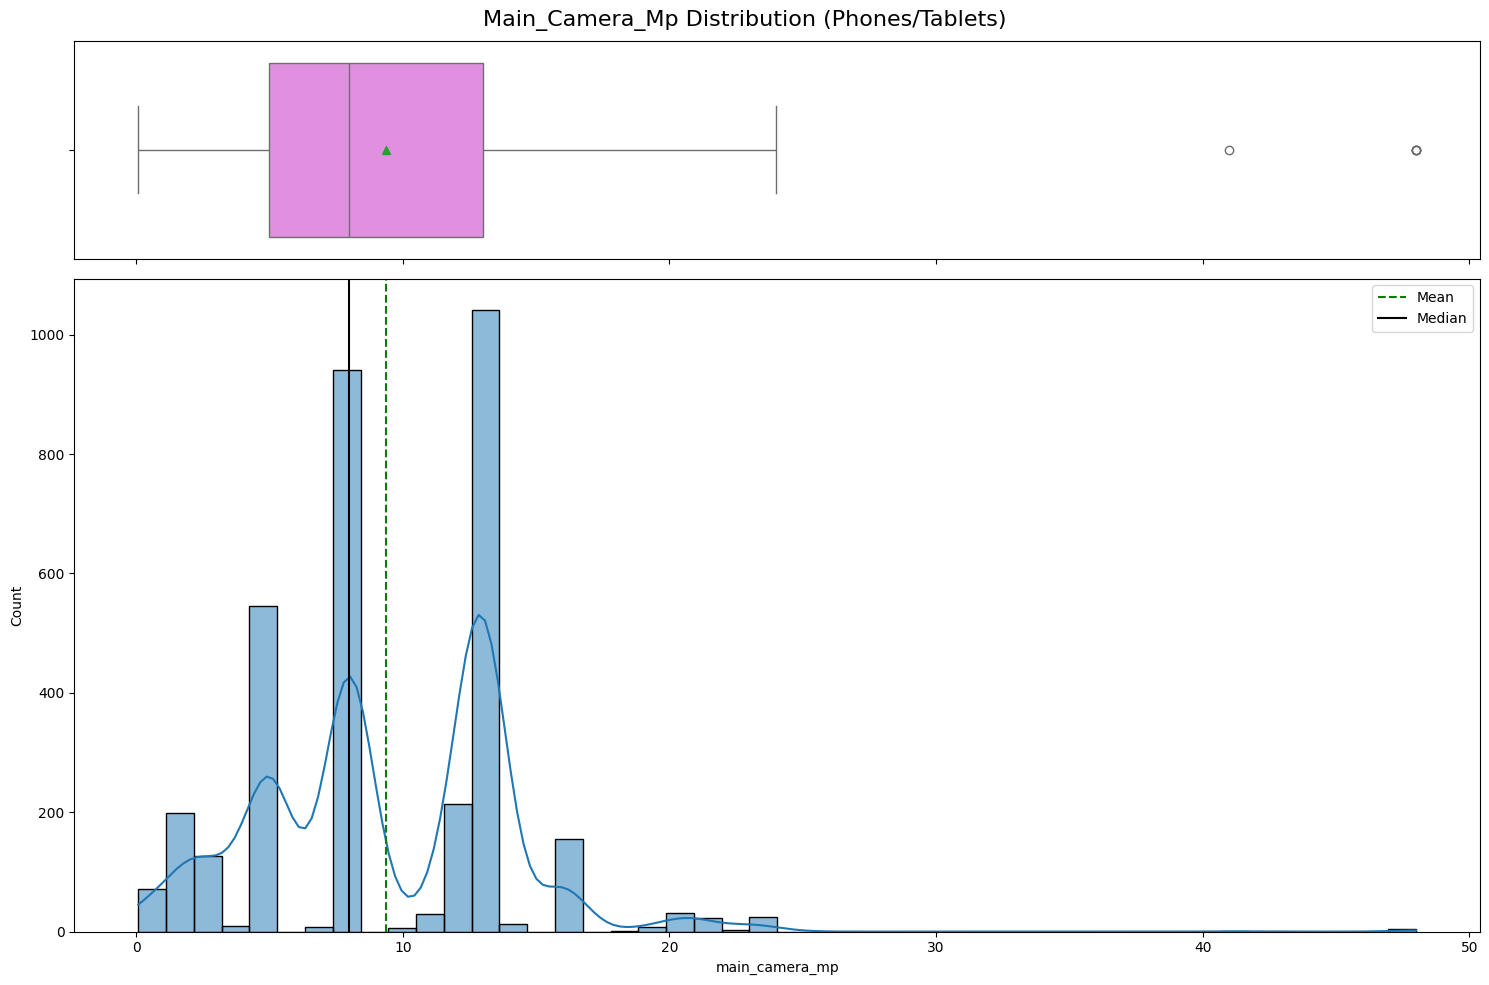

In [180]:
histogram_boxplot(device_data, "main_camera_mp")

* the distribution for the main_camera_mp column is right skewed with a median mp of less than 10, most being 14 mp and 8 mp
* there are a couple of outlying devices that have a higher mp

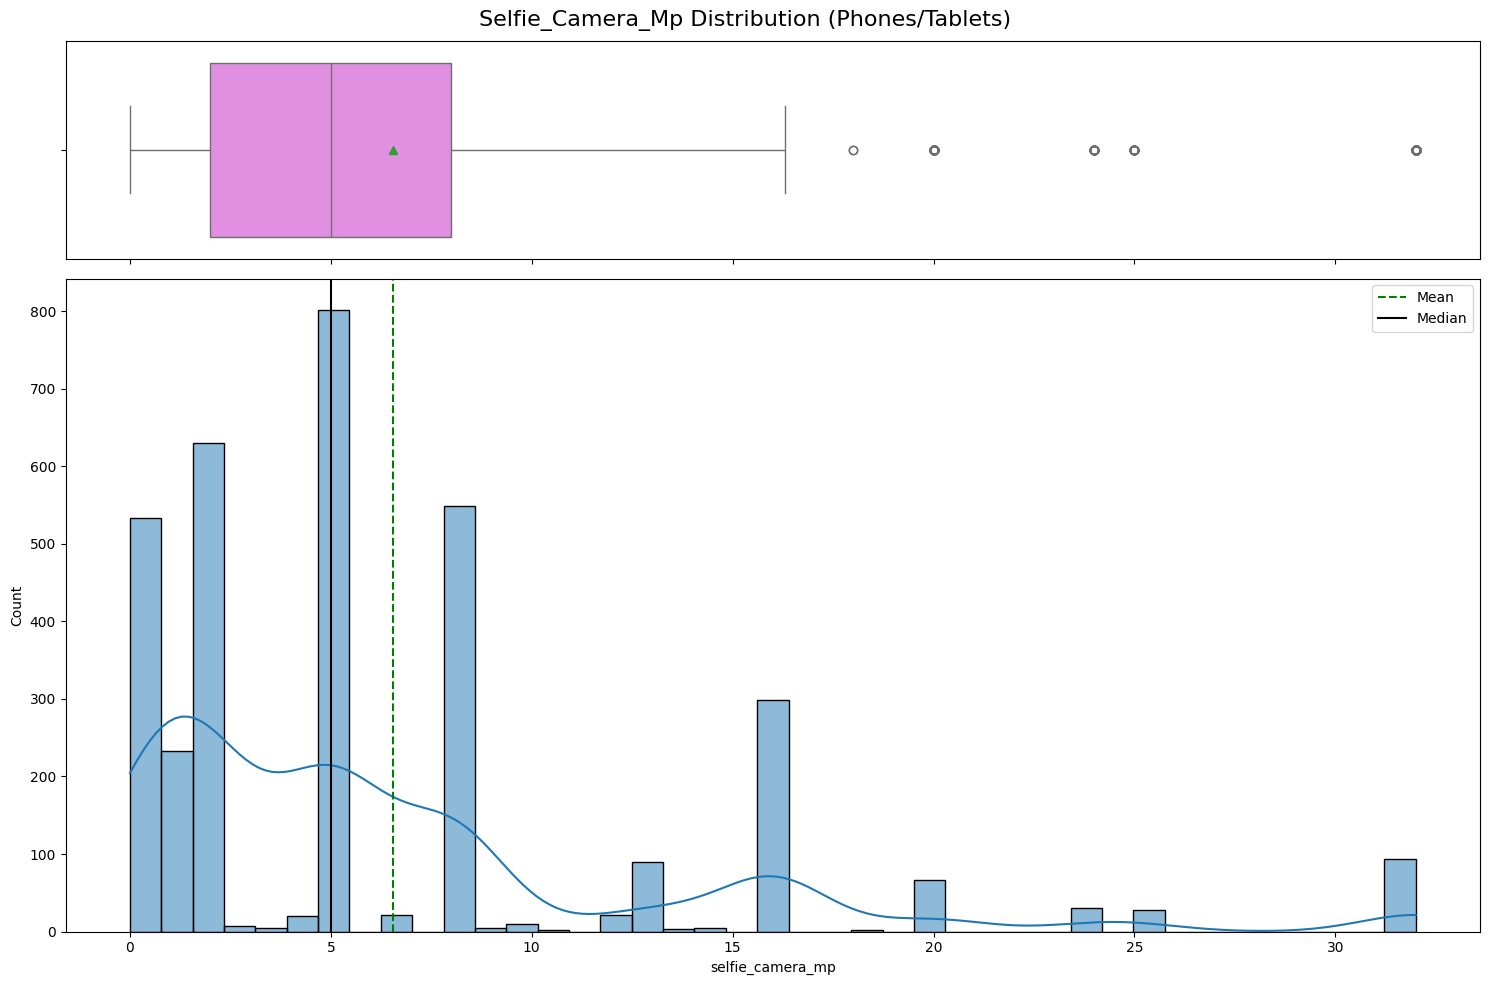

In [181]:
histogram_boxplot(device_data, "selfie_camera_mp")

* the distribution is right skewed, with most of the selfie cameras having less than 6 mp
* 5 mp is the most popular, then 3mp, then 7 mp, then 1 mp

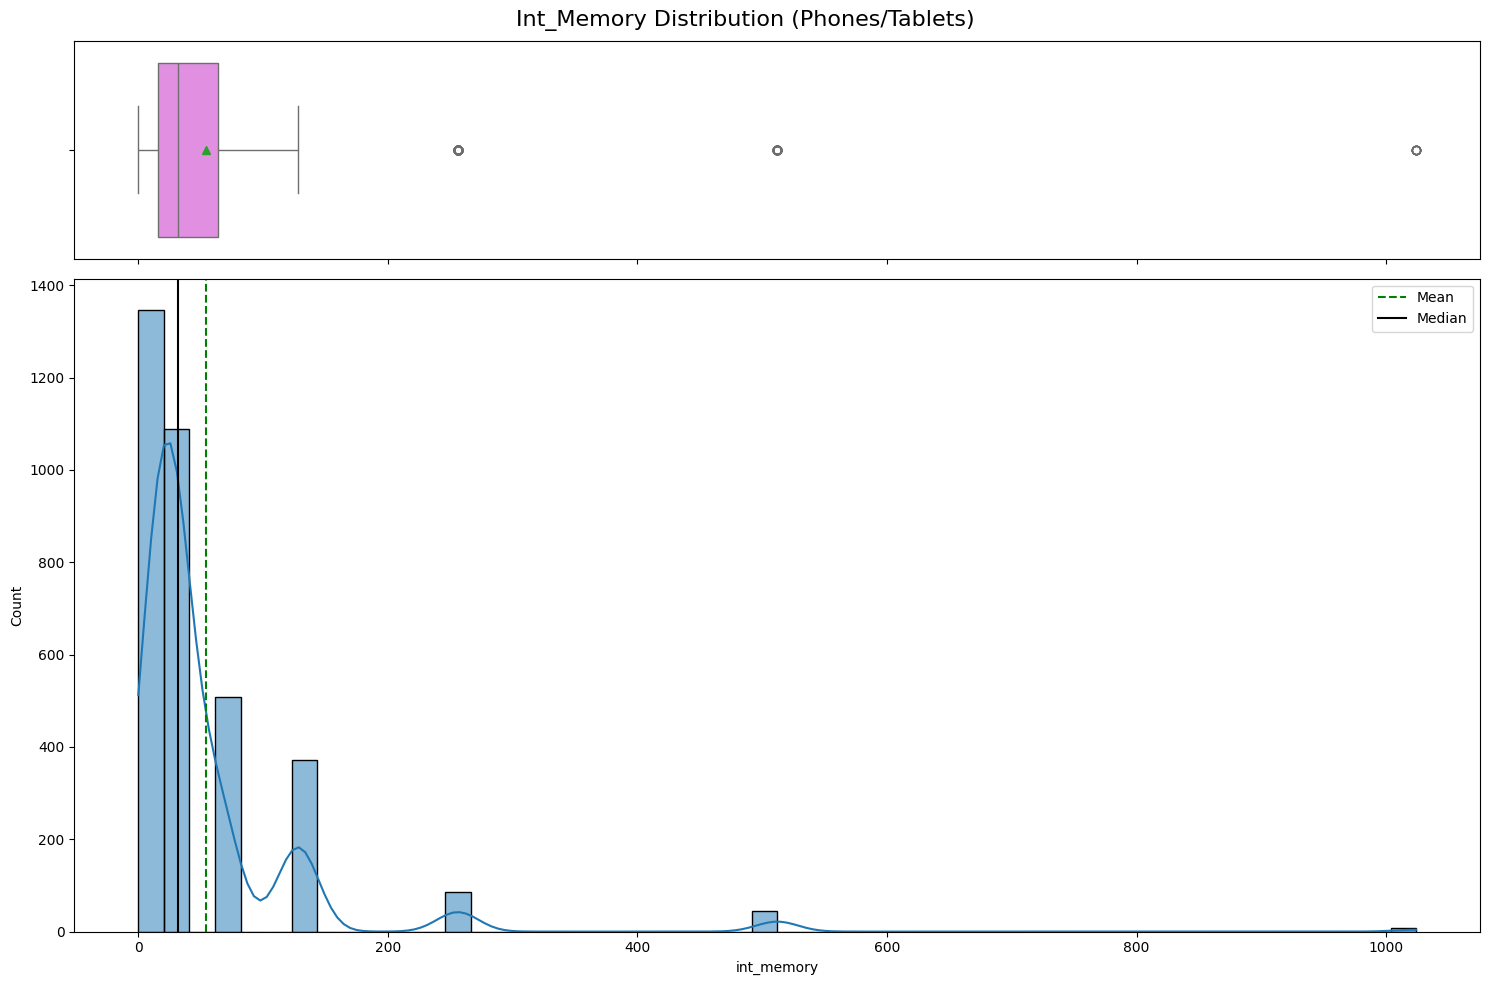

In [188]:
histogram_boxplot(device_data, "int_memory", bins=50)

* the distribution for internal memory is heavily right skewed, and most have less than 50 gb

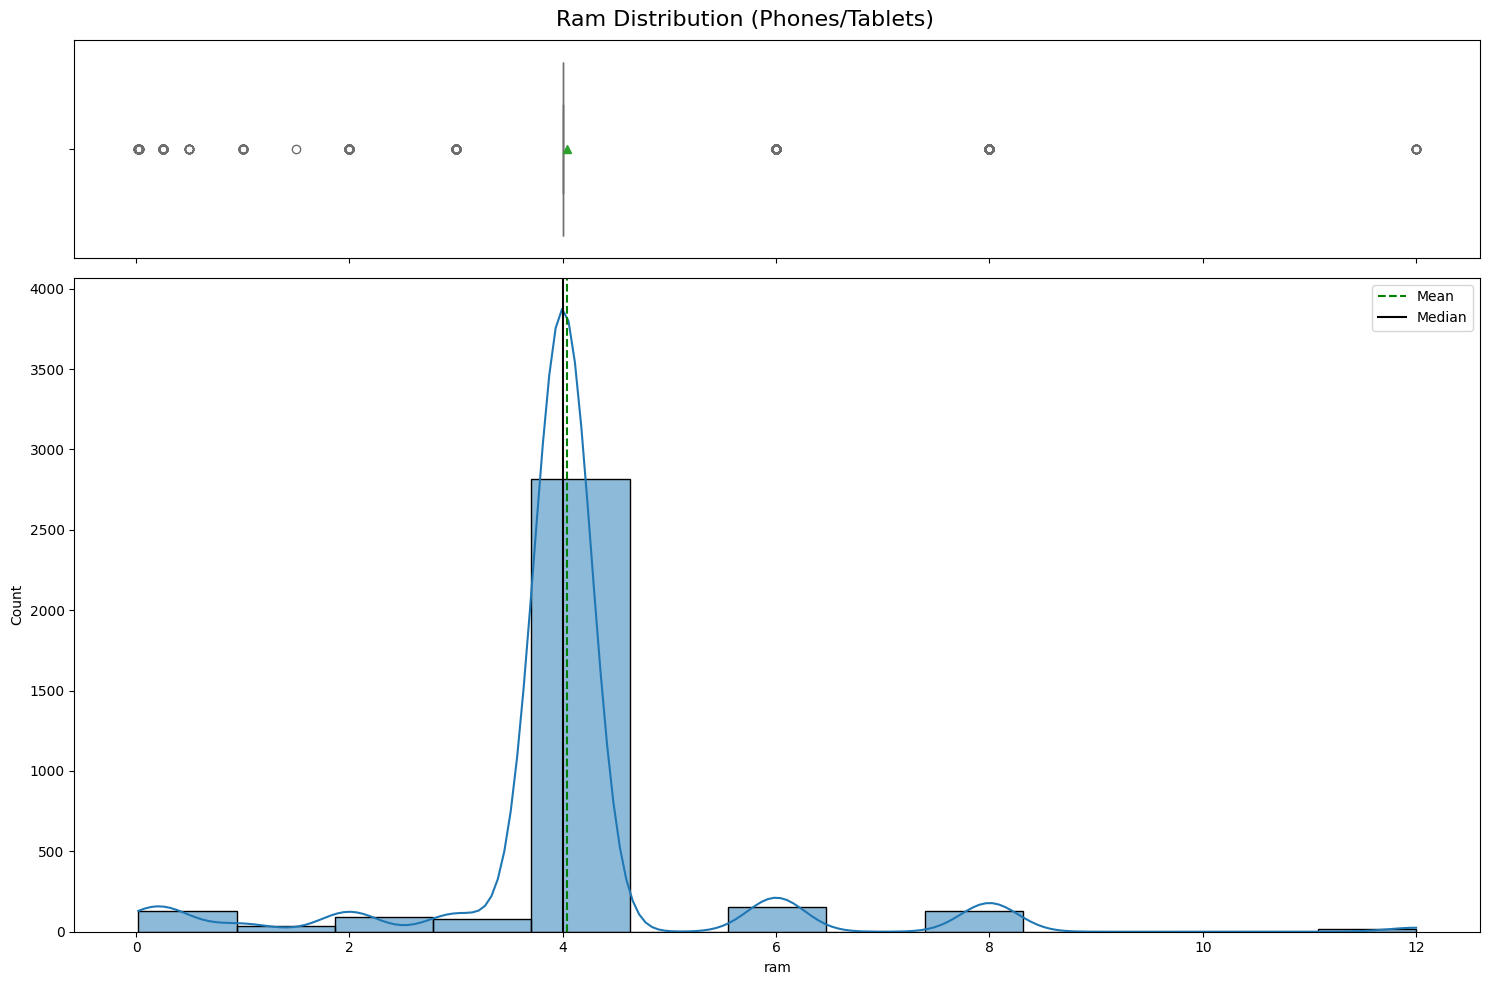

In [183]:
histogram_boxplot(device_data, "ram")

most phones have 4 gb of ram

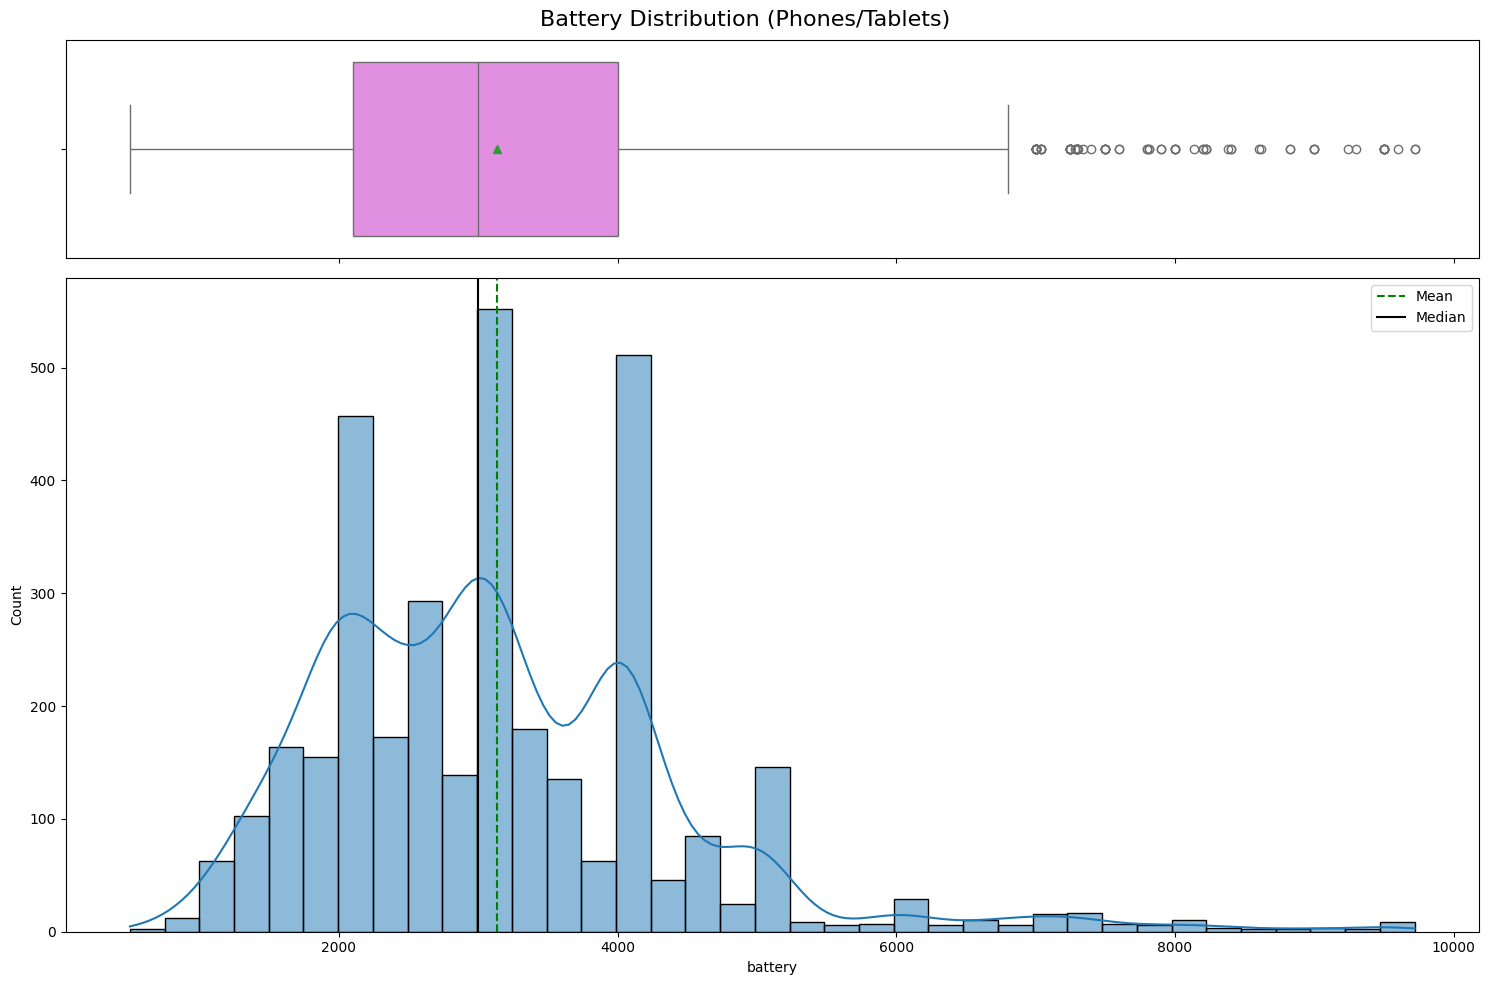

In [184]:
histogram_boxplot(device_data, "battery")

* most phones have 3000 mAh batteries, the 2nd most popular 4100 mAh, and 3rd with 2100 mAh 

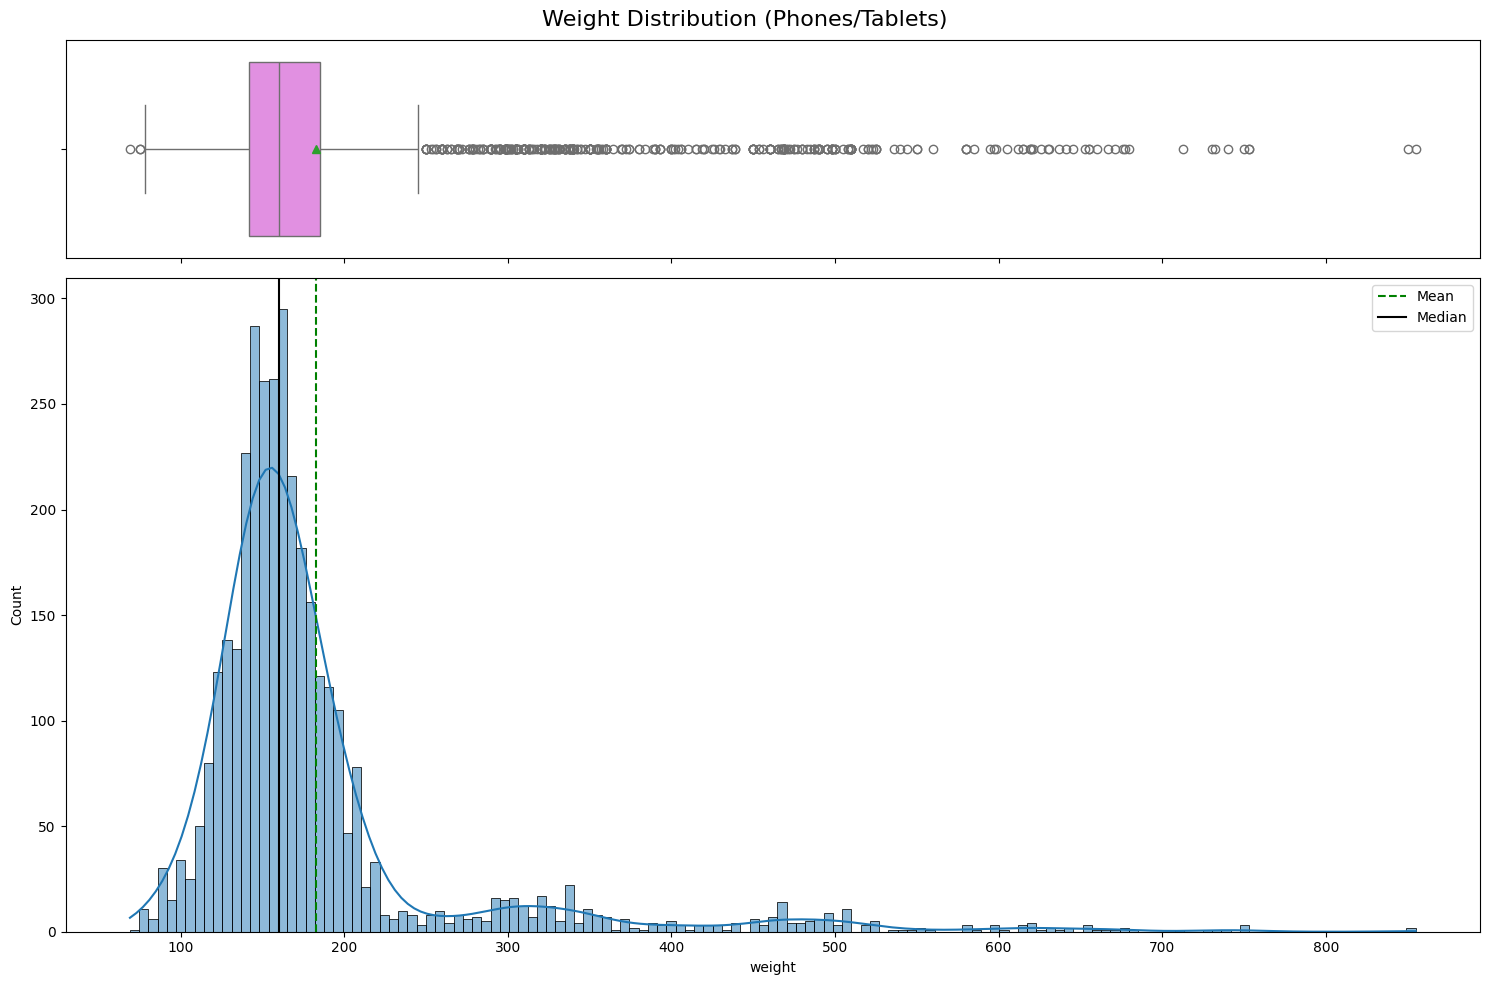

In [185]:
histogram_boxplot(device_data, "weight")

* the weight distribution for the weight column is right skewed with a median weight of less than 200 grams

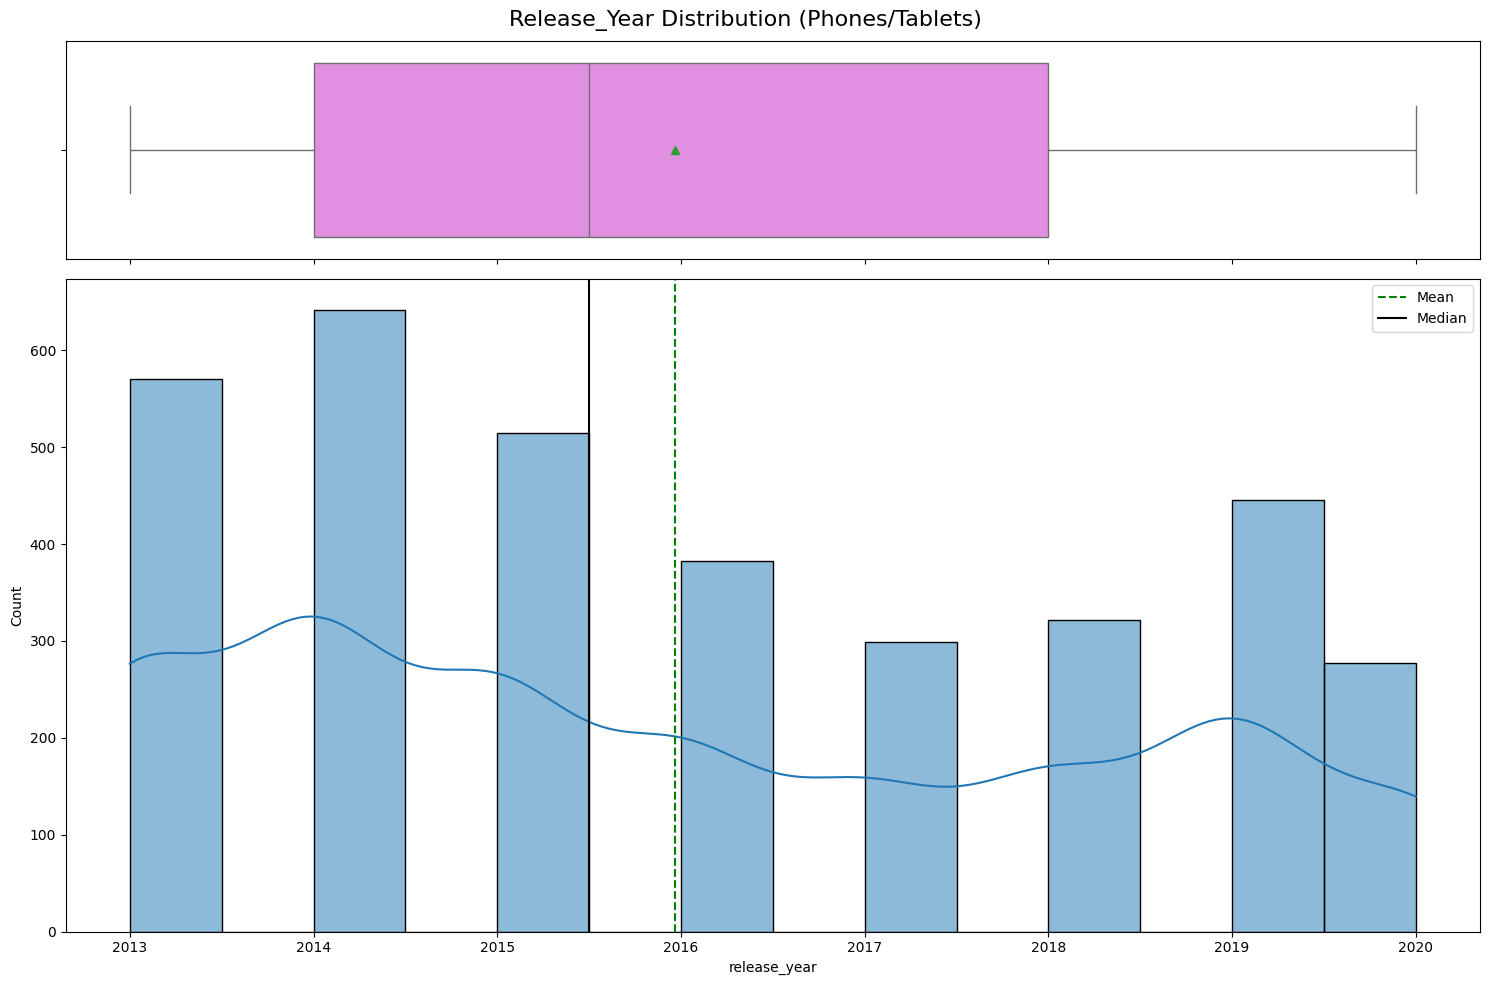

In [186]:
histogram_boxplot(device_data, "release_year")

* highest release was 2014 and 2017; older phones have the functionality most people need with newer phones not adding much

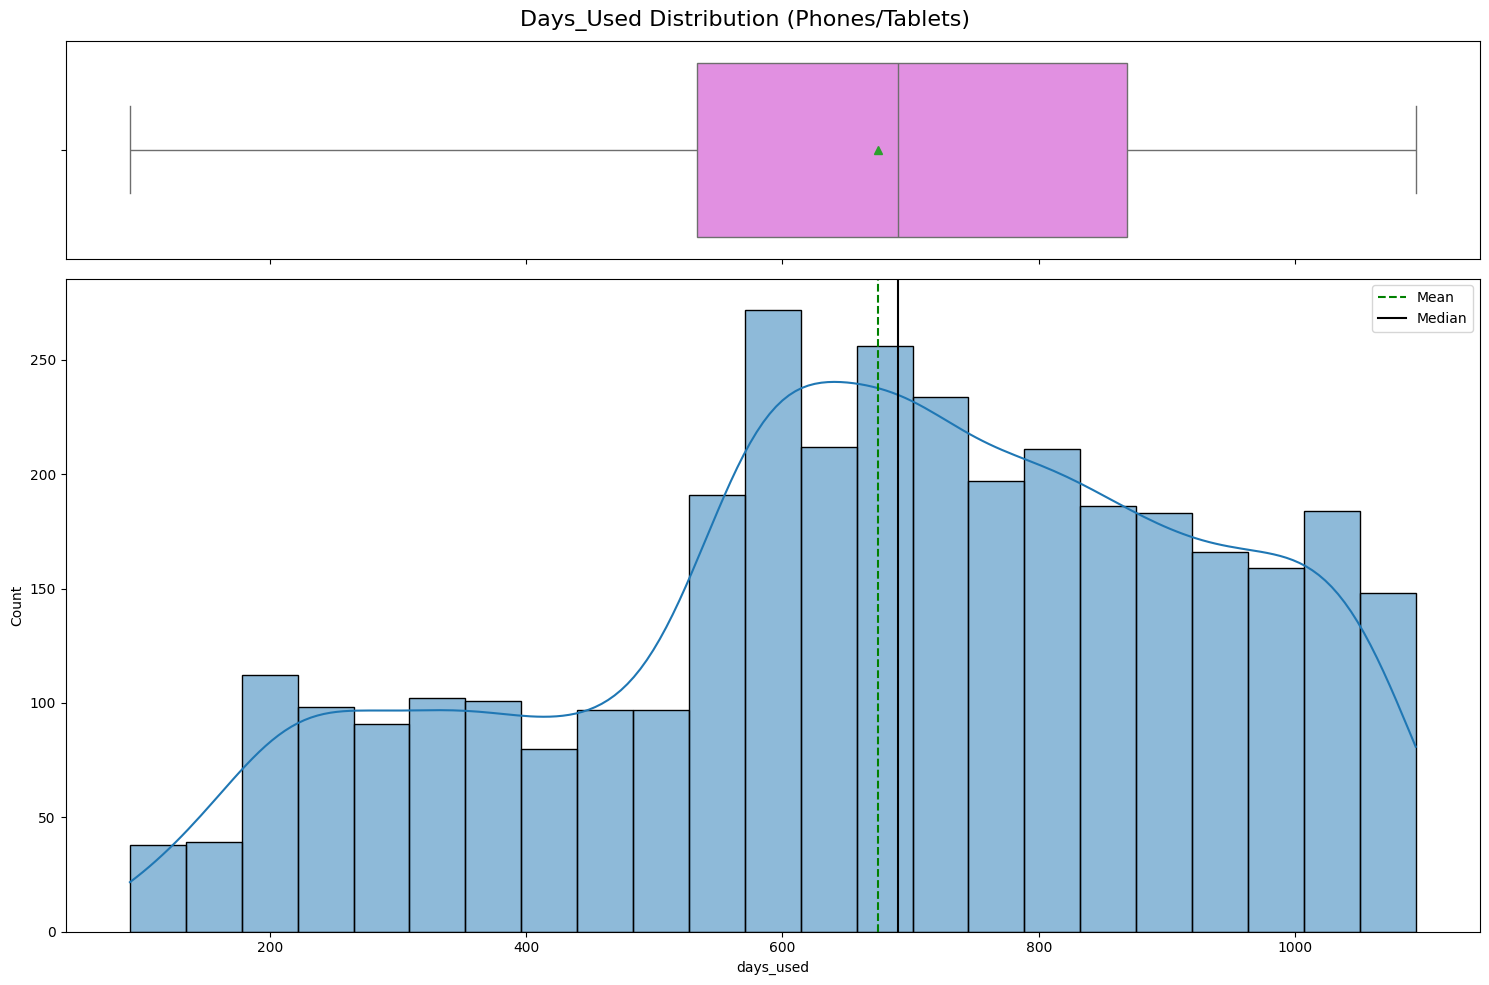

In [187]:
histogram_boxplot(device_data, "days_used")

* devices start becoming more popular after about a year and half. this makes sense since prices go down after the next device version is released and people are looking to sell their old devices to pay for a new one

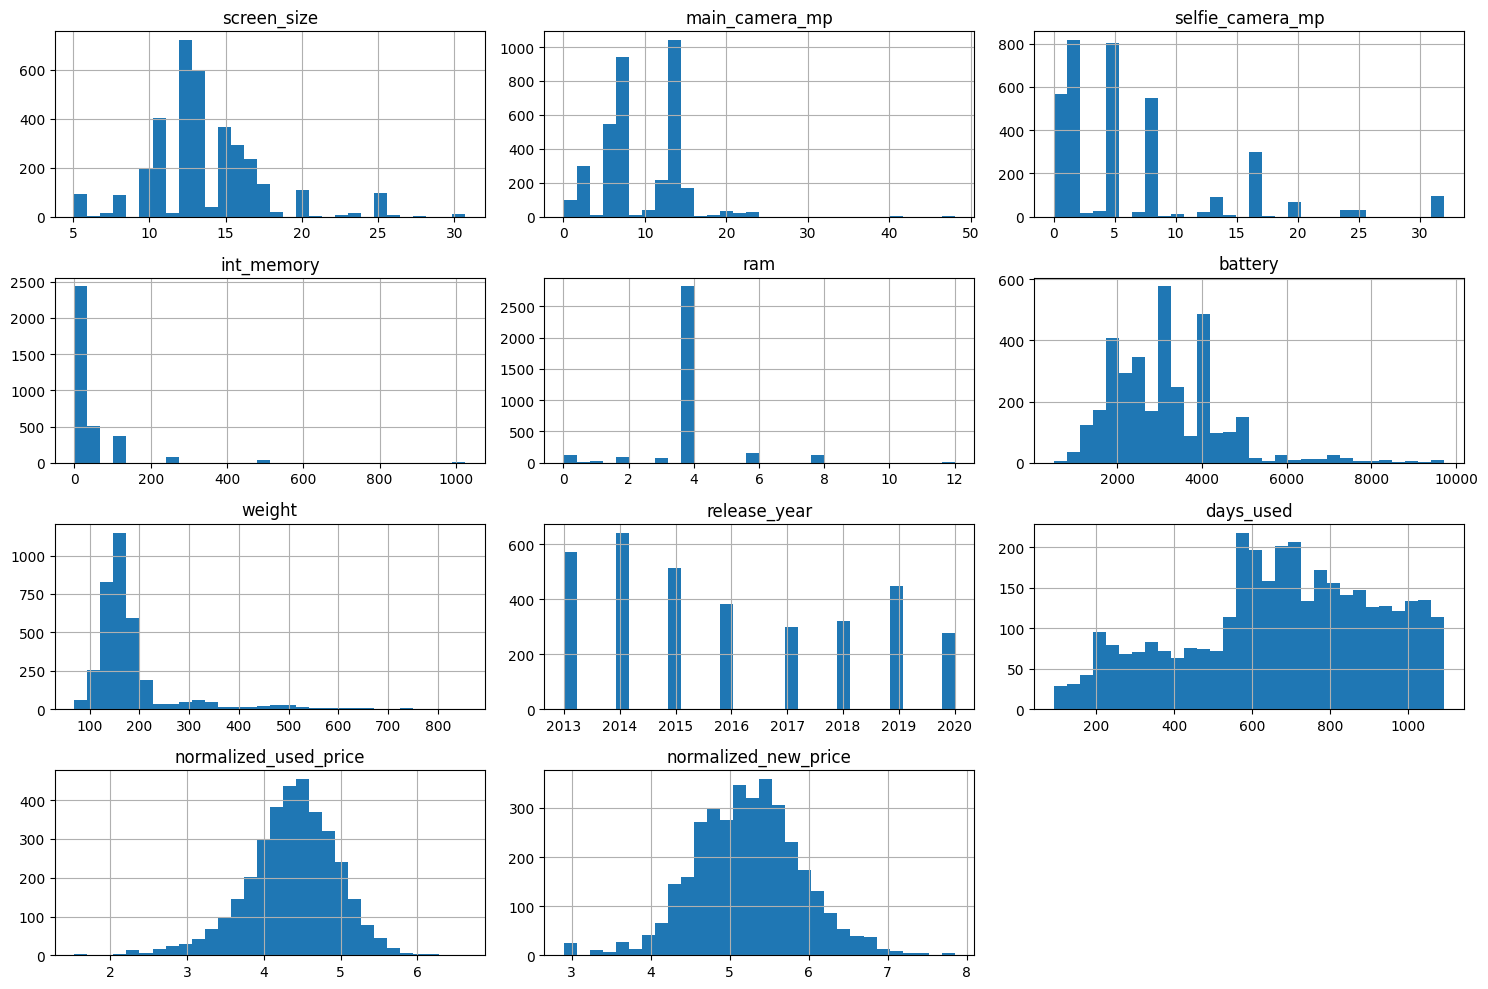

In [169]:
# Numeric univariate analysis
numeric_cols = device_data.select_dtypes(include='number').columns
device_data[numeric_cols].describe()

# Visuals (histograms)
device_data[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


In [192]:
# creating a list of numerical columns
num_cols = device_data.select_dtypes(include=np.number).columns.tolist()

# dropping release year from list of numerical columns as they are not numerical in nature
num_cols.remove("release_year")

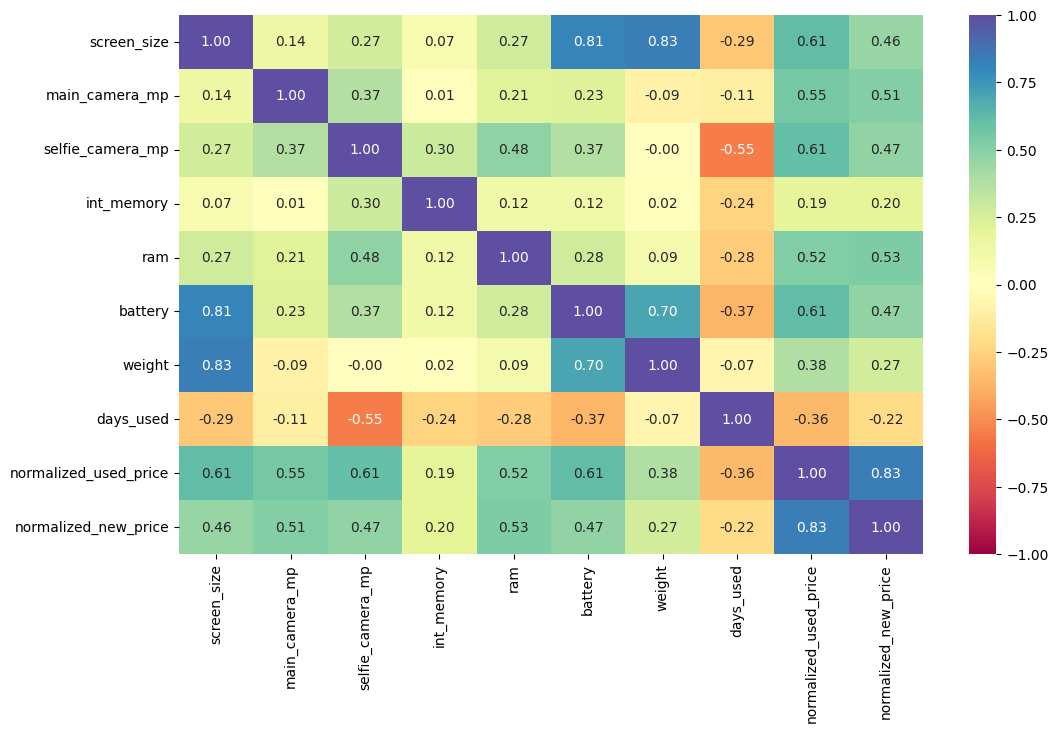

In [193]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    device_data[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

analysis of heat map:

* screen size's correlations are highest with battery and weight; the bigger the phone, the more battery power it needs, thus making it heavier
* main camera's highest correlation is the selfie camera 
* selfie camera correlation factor is the ram 

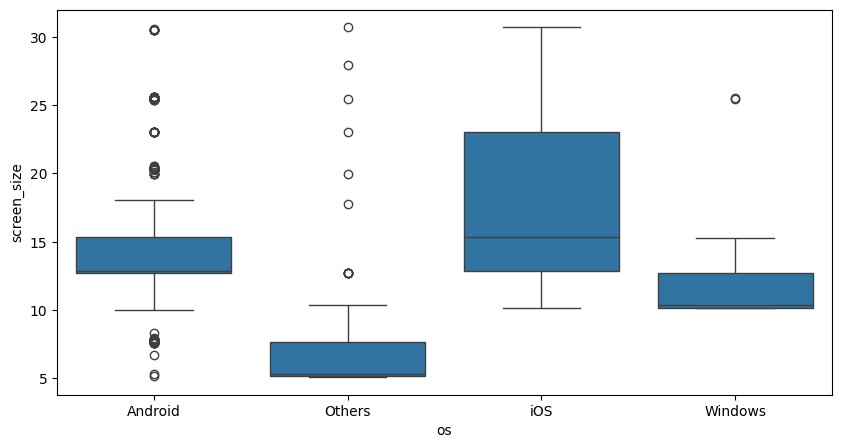

In [198]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=device_data, x="os", y="screen_size")
plt.show()

non-android/ios/windows devices have the smallest screens 

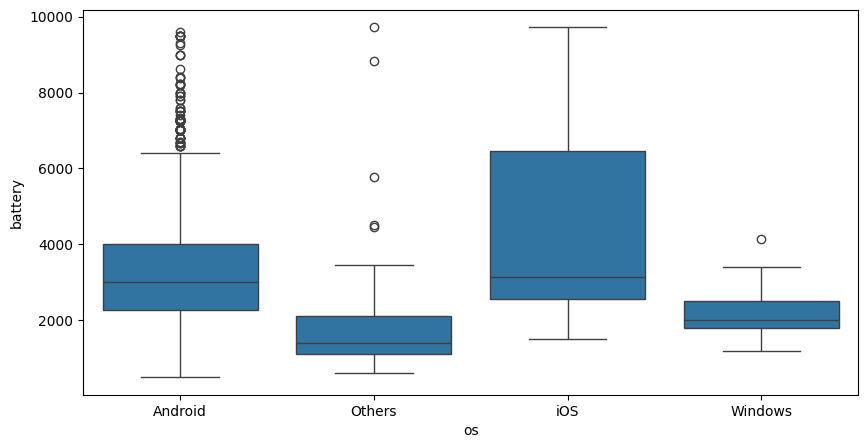

In [199]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=device_data, x="os", y="battery")
plt.show()

non-android/ios/windows devices have the smallest batteries

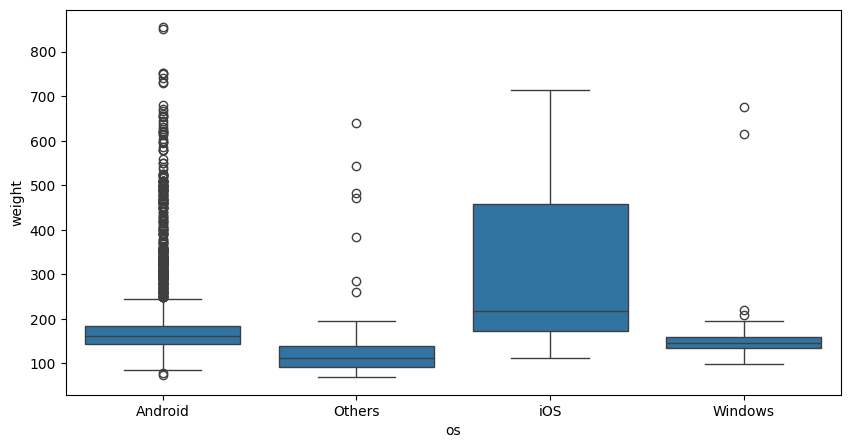

In [200]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=device_data, x="os", y="weight")
plt.show()

non-android/ios/windows devices have the lightest devices

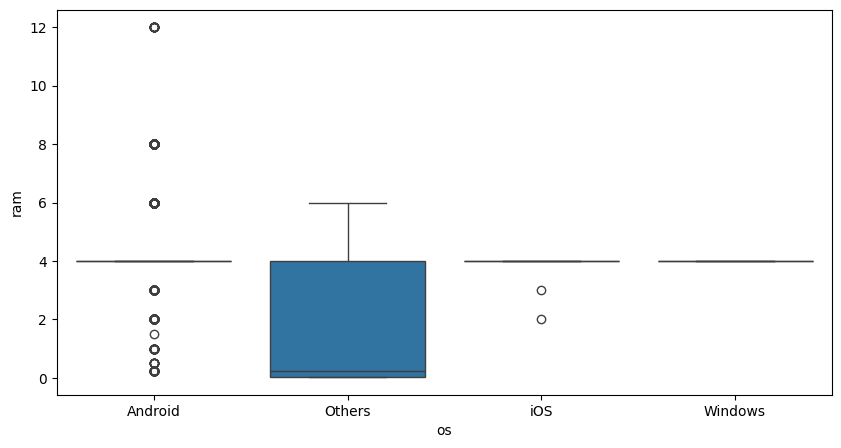

In [197]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=device_data, x="os", y="ram")
plt.show()

non-android/ios/windows devices have the largest variation of ram

In [108]:
categorical_cols = device_data.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col} distribution:\n", device_data[col].value_counts().head(10))



brand_name distribution:
 Others     502
Samsung    341
Huawei     251
LG         201
Lenovo     171
ZTE        140
Xiaomi     132
Oppo       129
Asus       122
Alcatel    121
Name: brand_name, dtype: int64

os distribution:
 Android    3214
Others      137
Windows      67
iOS          36
Name: os, dtype: int64

4g distribution:
 yes    2335
no     1119
Name: 4g, dtype: int64

5g distribution:
 no     3302
yes     152
Name: 5g, dtype: int64


insight: android samsung 4g phones are the most popular

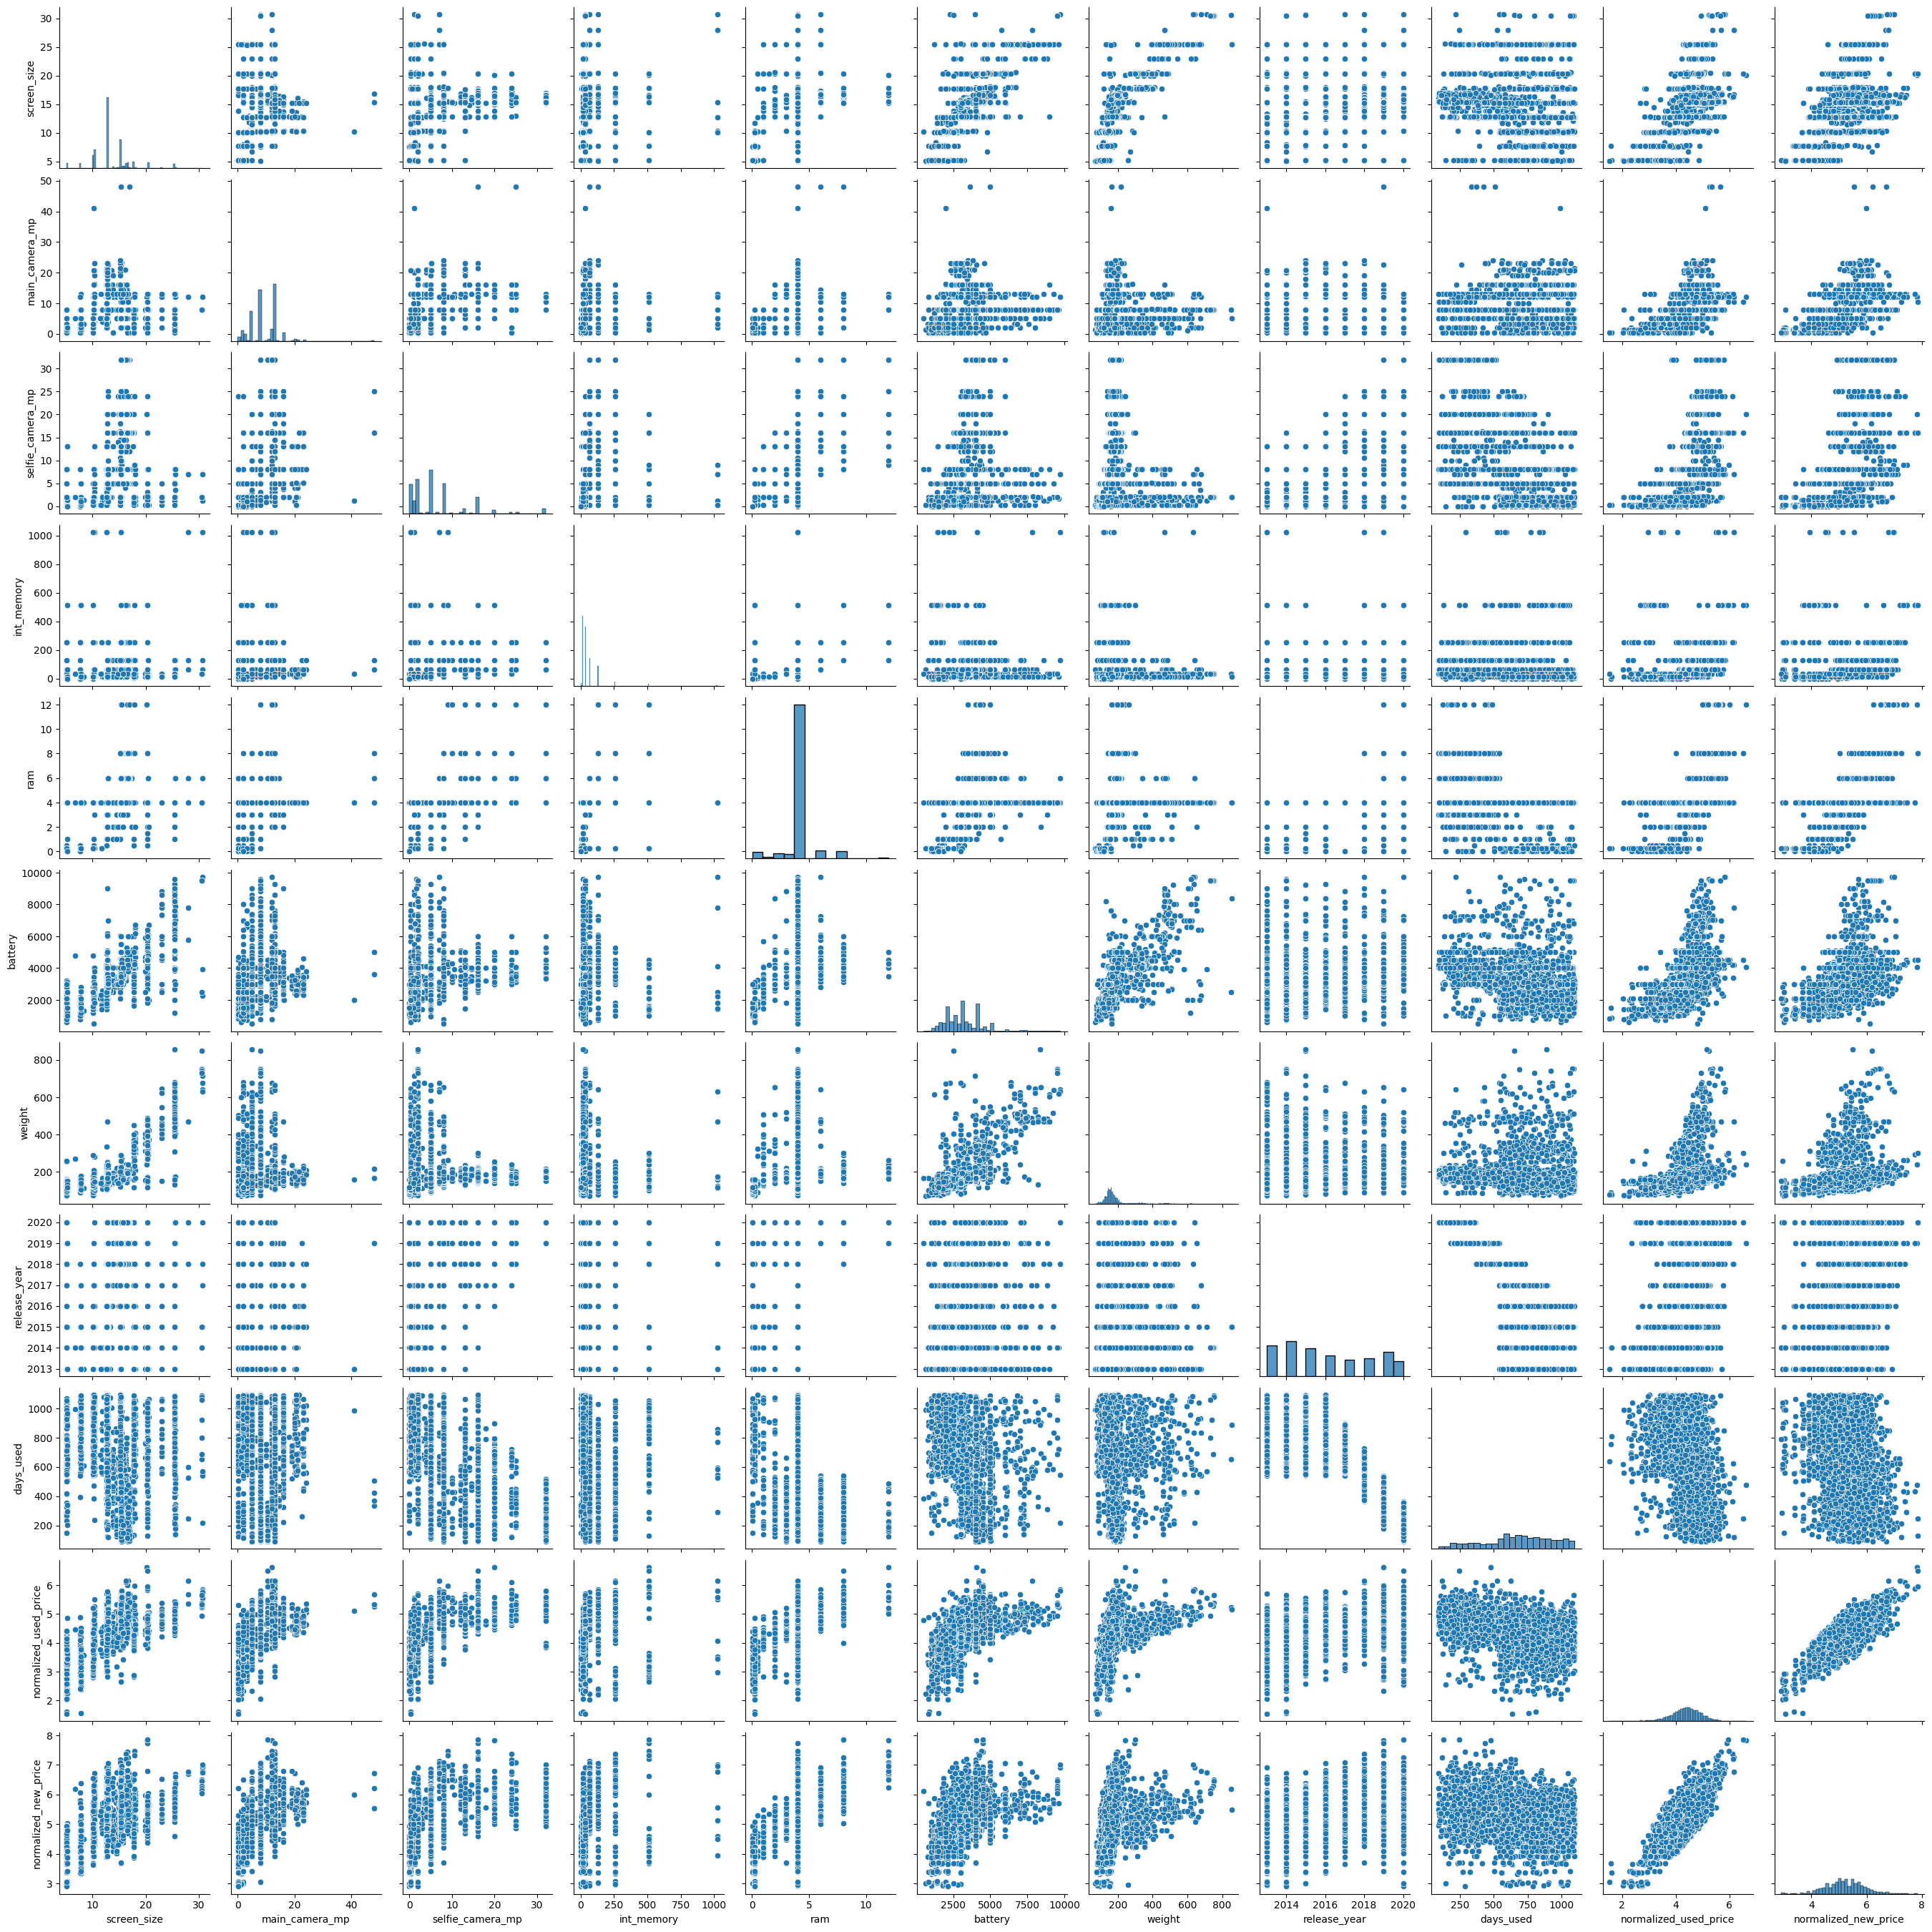

Correlation matrix:
                        screen_size  main_camera_mp  selfie_camera_mp  \
screen_size                  1.000           0.139             0.272   
main_camera_mp               0.139           1.000             0.374   
selfie_camera_mp             0.272           0.374             1.000   
int_memory                   0.072           0.010             0.297   
ram                          0.274           0.211             0.477   
battery                      0.811           0.226             0.370   
weight                       0.829          -0.088            -0.005   
release_year                 0.364           0.302             0.691   
days_used                   -0.292          -0.108            -0.552   
normalized_used_price        0.615           0.552             0.608   
normalized_new_price         0.461           0.513             0.474   

                       int_memory    ram  battery  weight  release_year  \
screen_size                 0.072  0.27

In [170]:
numeric_correlation_matrix = device_data.select_dtypes(include='number').columns
sns.pairplot(device_data[numeric_correlation_matrix])
plt.show()

# Top correlations
print("Correlation matrix:\n", device_data[numeric_correlation_matrix].corr().round(3))


**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

normalized_used_price: Mean=4.36, Median=4.41, Q1=4.03, Q3=4.76, IQR=0.72


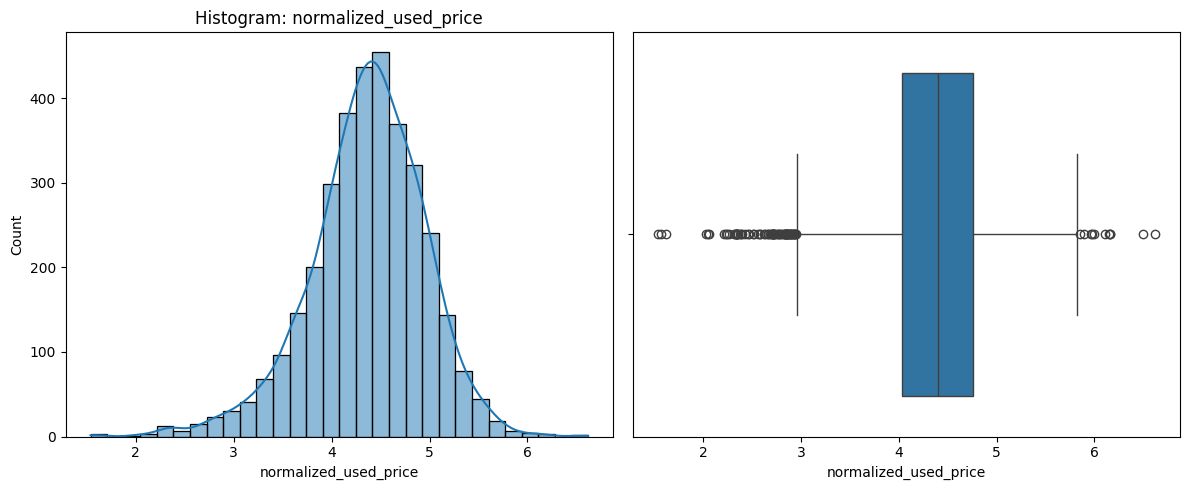

In [171]:
# 1. What does the distribution of normalized used device prices look like?
# Distribution of normalized used device prices
nup = 'normalized_used_price'

plt.figure(figsize=(12, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(data=device_data, x=nup, bins=30, kde=True)
plt.title(f'Histogram: {nup}')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=device_data, x=nup)
Q1 = device_data[nup].quantile(0.25)
Q3 = device_data[nup].quantile(0.75)
median = device_data[nup].median()
IQR = Q3 - Q1
print(f"{nup}: Mean={device_data[nup].mean():.2f}, Median={median:.2f}, Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")

plt.tight_layout()
plt.show()


* Left-skewed bell curve—most used devices ~4.5 (mid-value), few cheap (<4) or premium (>5)
* Used devices cluster mid-range; target marketing at 4-5 score sweet spot. Boxplot confirms: 75% under 5.0, outliers to 6+ and 3-

In [172]:
#2. What percentage of the used device market is dominated by Android devices?
# Percentage of Android devices
total_devices = len(device_data)
android_count = (device_data['os'] == 'Android').sum()  

android_percentage = (android_count / total_devices) * 100
print(f"Android dominates {android_percentage:.1f}% of used device market")
android_count = device_data[device_data['os'].str.contains('Android', na=False)].shape[0]


Android dominates 93.1% of used device market


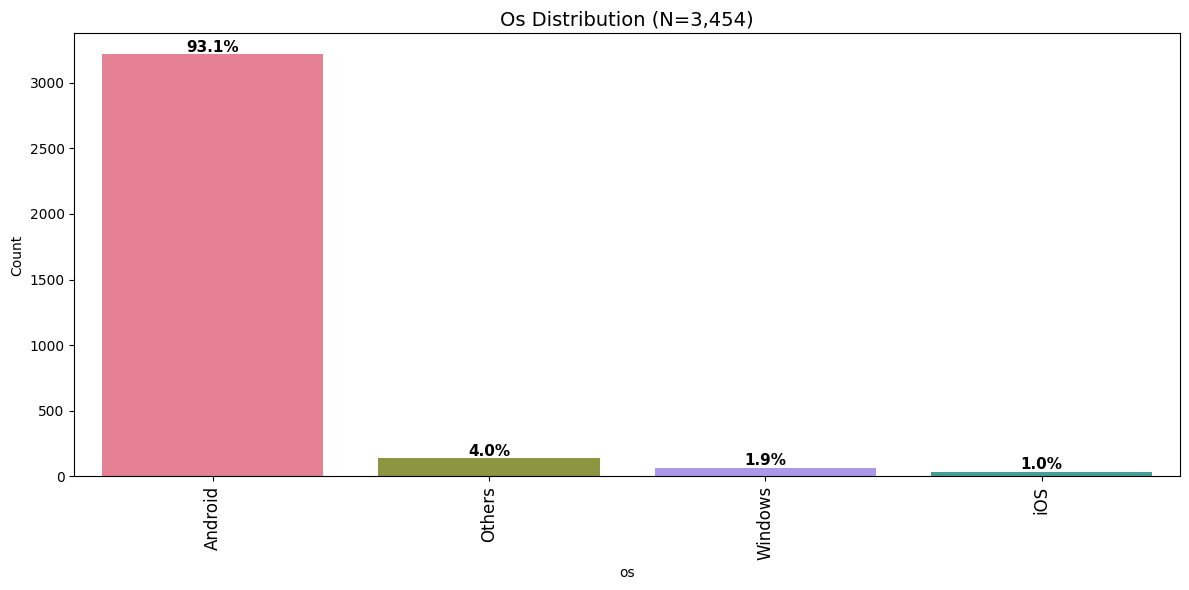

In [209]:
labeled_barplot(device_data, "os", perc=True)

Android dominates 93.1% of used device market

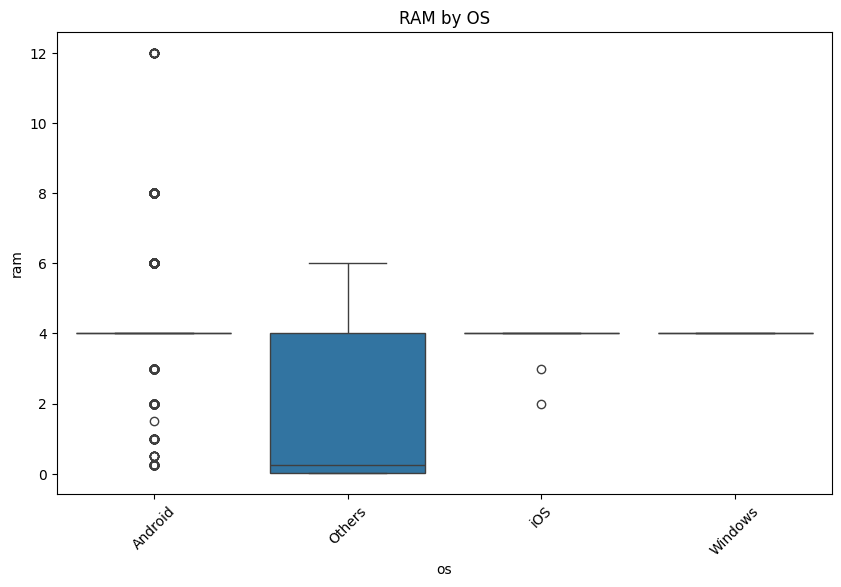

In [112]:
#3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
# RAM by OS (boxplot + stats)

plt.figure(figsize=(10, 6))
sns.boxplot(data=device_data, x='os', y='ram')
plt.title('RAM by OS')
plt.xticks(rotation=45)
plt.show()

* medians align at ~4GB across Android/iOS/Windows
* Androids have a wide spread (2-12GB outliers) due to budget-to-flagship variety.​
* iOS has a tight box (consistent 4GB, few low outliers).​
* Windows has a tight box (consistent 4GB, no outliers)
* Other phones sit at low RAM (around 0–2 GB) with a few going up to 4–6 GB. They are likely cheap/basic phones or niche devices

Weight comparison (in grams):
          Phone  Tablet
count   3113.0   341.0
mean     166.4   332.3
median   156.0   300.0
min       69.0   118.0
max      850.0   855.0


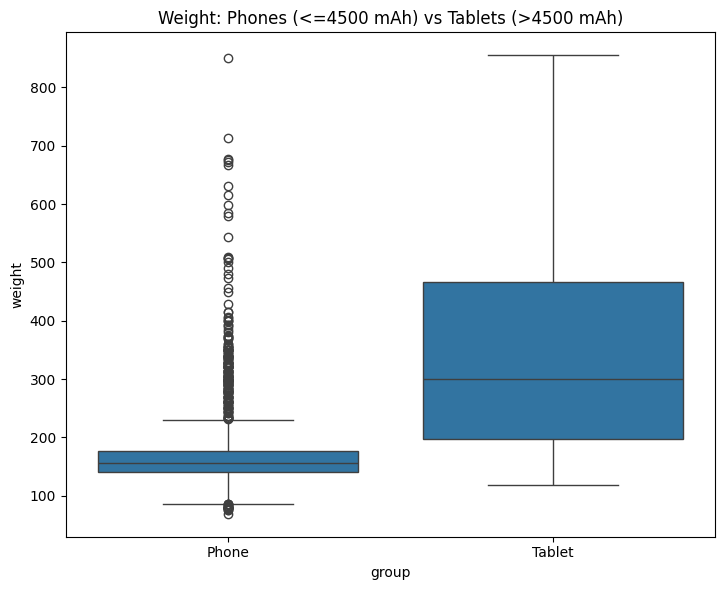

In [113]:
#4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?

phones = device_data[device_data['battery'] <= 4500]  
tablets = device_data[device_data['battery'] > 4500]   

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
combined = pd.concat([phones.assign(group='Phone'), tablets.assign(group='Tablet')])
sns.boxplot(data=combined, x='group', y='weight')
plt.title('Weight: Phones (<=4500 mAh) vs Tablets (>4500 mAh)')

all_stats = pd.concat([phones['weight'].agg(['count', 'mean', 'median', 'min', 'max']).rename('Phone'),
                      tablets['weight'].agg(['count', 'mean', 'median', 'min', 'max']).rename('Tablet')], axis=1)
print("Weight comparison (in grams):\n", all_stats.round(1))

plt.tight_layout()
plt.show()




insights:
* tablets are at least twice as heavy than phones, with many outlier devices <4500 mah weighing above 250 grams, up to over 700 grams 

In [120]:
#5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
large_screen_by_os = device_data[device_data['screen_size'] > 6]

# By OS  
os_counts = large_screen_by_os.groupby('os')['os'].value_counts().unstack(fill_value=0)
print("\nPhones/Tablets (>6in) by OS:\n", os_counts)

small_screen = device_data[device_data['screen_size'] < 6]
print("\nSmall screens (<6in):\n", small_screen['os'].value_counts().sort_index())



Phones/Tablets (>6in) by OS:
 os       Android  Others  Windows  iOS
os                                    
Android     3212       0        0    0
Others         0      47        0    0
Windows        0       0       67    0
iOS            0       0        0   36

Small screens (<6in):
 Android     2
Others     90
Name: os, dtype: int64


In [122]:
large_screen_by_brand_name = device_data[device_data['screen_size'] > 6]

# By brand name 
brand_name_counts = large_screen_by_brand_name['brand_name'].value_counts().sort_values(ascending=False)
print("\nPhones/Tablets (>6in) by Brand Name:\n", brand_name_counts)


Phones/Tablets (>6in) by Brand Name:
 Others        479
Samsung       334
Huawei        251
LG            197
Lenovo        171
ZTE           140
Xiaomi        132
Oppo          129
Asus          122
Vivo          117
Honor         116
Alcatel       115
HTC           110
Micromax      108
Motorola      106
Sony           86
Nokia          72
Meizu          62
Gionee         56
Acer           51
XOLO           49
Panasonic      47
Realme         41
Apple          39
Lava           36
Spice          30
Karbonn        29
Celkon         25
Coolpad        22
OnePlus        22
Microsoft      22
BlackBerry     21
Google         15
Infinix        10
Name: brand_name, dtype: int64


In [123]:
small_screen = device_data[device_data['screen_size'] < 6]
print("\nSmall screens (<6in):\n", small_screen['brand_name'].value_counts().sort_values(ascending=False))


Small screens (<6in):
 Nokia         34
Others        23
Micromax       9
Celkon         8
Samsung        7
Alcatel        6
LG             4
BlackBerry     1
Name: brand_name, dtype: int64


In [176]:
total_large_screens = len(large_screen_by_os)
print(f"Total devices with large screens (>6in): {total_large_screens}")

Total devices with large screens (>6in): 3362


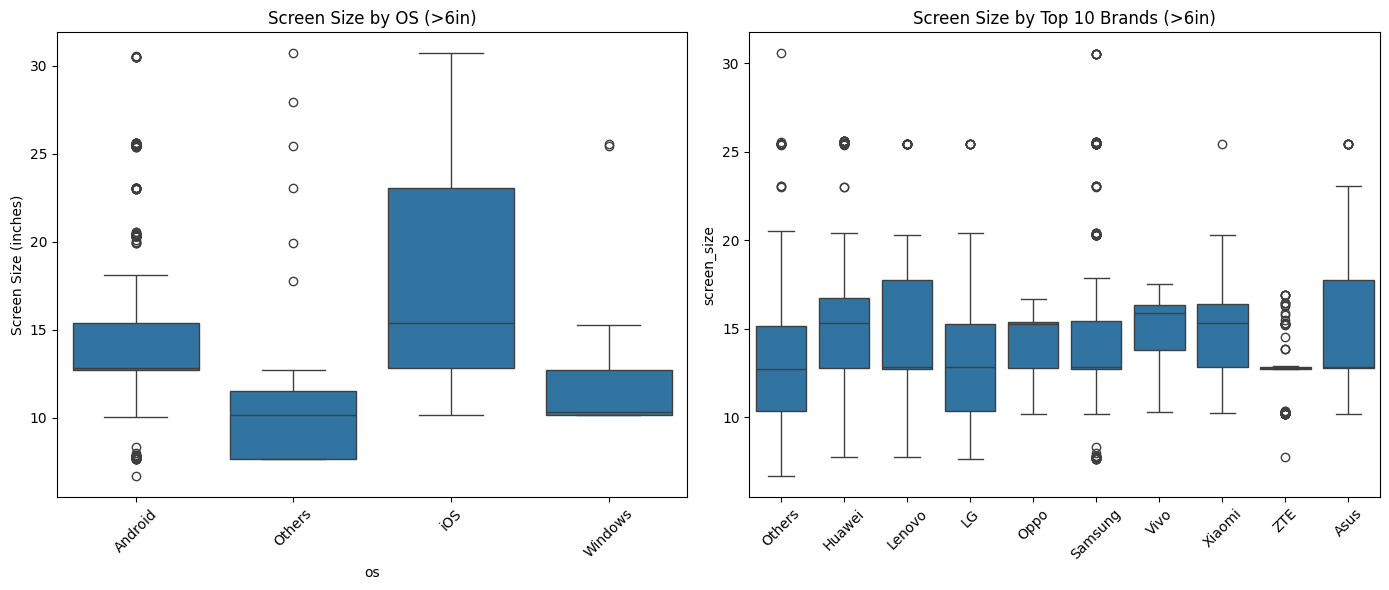

Dataset: 3,362 devices >6in


In [215]:
large_screen = device_data[device_data['screen_size'] > 6]

plt.figure(figsize=(14, 6))

# Left: Boxplot by OS
plt.subplot(1, 2, 1)
sns.boxplot(data=large_screen, x='os', y='screen_size')
plt.title('Screen Size by OS (>6in)')
plt.xticks(rotation=45)
plt.ylabel('Screen Size (inches)')

# Right: Top brands boxplot
plt.subplot(1, 2, 2)
top_brands = large_screen.groupby('brand_name').size().nlargest(10).index
sns.boxplot(data=large_screen[large_screen['brand_name'].isin(top_brands)], 
            x='brand_name', y='screen_size')
plt.title('Screen Size by Top 10 Brands (>6in)')
plt.xticks(rotation=45)
plt.xlabel('')

plt.tight_layout()
plt.show()

print(f"Dataset: {len(large_screen):,} devices >6in")


insights:
* phones with screens over 6 inches are available from 14 brands, but most come from just 4: Samsung (highest count), Huawei, LG, and Lenovo dominate the big-screen phone market, totalling 3362 devices.

In [135]:
#6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?

# >8MP selfie: brand_name × OS crosstab (all OS)
good_selfie = device_data[device_data['selfie_camera_mp'] > 8]

crosstab = pd.crosstab(good_selfie['brand_name'], good_selfie['os'], margins=True)
print("Selfie >8MP by brand_name × OS:\n", crosstab)


Selfie >8MP by brand_name × OS:
 os          Android  Others  All
brand_name                      
Acer              1       0    1
Asus              6       0    6
BlackBerry        2       0    2
Coolpad           3       0    3
Gionee            4       0    4
HTC              20       0   20
Honor            41       0   41
Huawei           87       0   87
Infinix           4       0    4
LG               30       2   32
Lenovo           14       0   14
Meizu            24       0   24
Micromax          2       0    2
Motorola         26       0   26
Nokia            10       0   10
OnePlus          18       0   18
Oppo             75       0   75
Others           34       0   34
Panasonic         2       0    2
Realme           18       0   18
Samsung          57       0   57
Sony             14       0   14
Vivo             78       0   78
Xiaomi           63       0   63
ZTE              20       0   20
All             653       2  655


In [138]:
print("\nBrand totals:\n", good_selfie['brand_name'].value_counts())


Brand totals:
 Huawei        87
Vivo          78
Oppo          75
Xiaomi        63
Samsung       57
Honor         41
Others        34
LG            32
Motorola      26
Meizu         24
HTC           20
ZTE           20
Realme        18
OnePlus       18
Lenovo        14
Sony          14
Nokia         10
Asus           6
Infinix        4
Gionee         4
Coolpad        3
BlackBerry     2
Micromax       2
Panasonic      2
Acer           1
Name: brand_name, dtype: int64


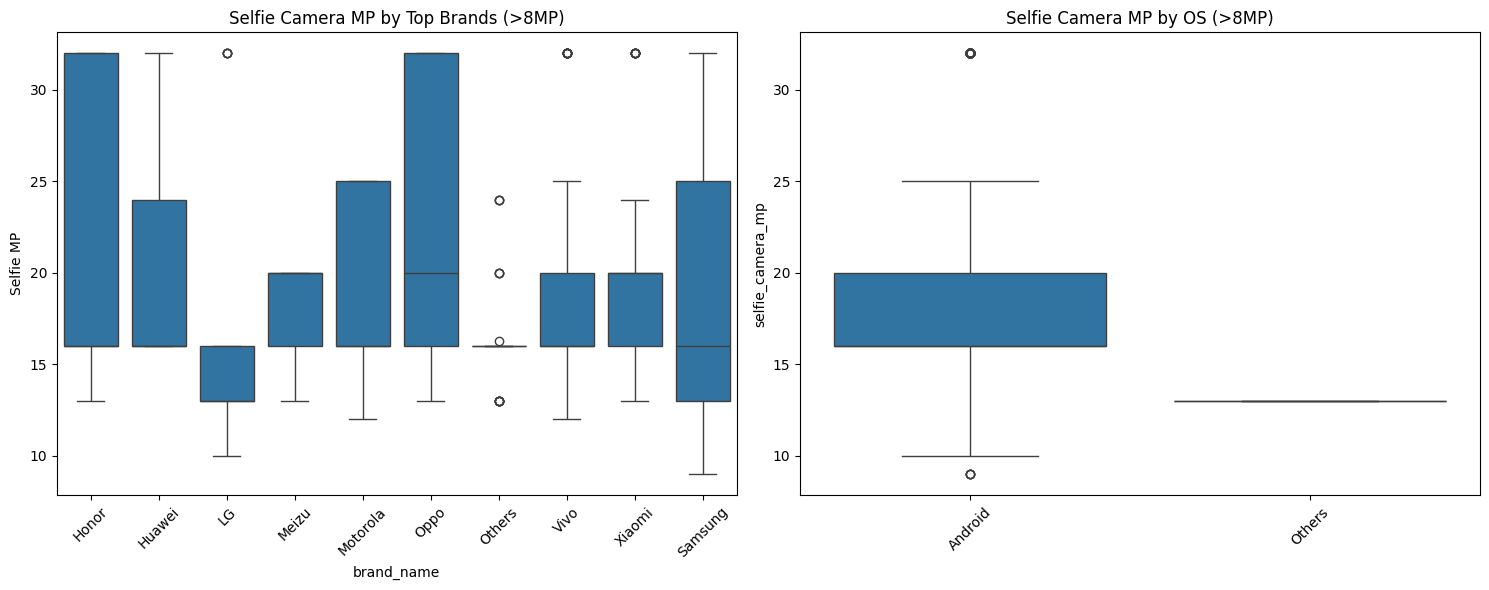

Total devices >8MP selfie: 655
Top brands:
 Huawei     87
Vivo       78
Oppo       75
Xiaomi     63
Samsung    57
Name: brand_name, dtype: int64


In [216]:
#6. Selfie >8MP distribution by brand/OS.

good_selfie = device_data[device_data['selfie_camera_mp'] > 8]

plt.figure(figsize=(15, 6))

# Left: Boxplot by brand (top 10)
plt.subplot(1, 2, 1)
top_brands = good_selfie['brand_name'].value_counts().head(10).index
sns.boxplot(data=good_selfie[good_selfie['brand_name'].isin(top_brands)], 
            x='brand_name', y='selfie_camera_mp')
plt.title('Selfie Camera MP by Top Brands (>8MP)')
plt.xticks(rotation=45)
plt.ylabel('Selfie MP')

# Right: Boxplot by OS
plt.subplot(1, 2, 2)
sns.boxplot(data=good_selfie, x='os', y='selfie_camera_mp')
plt.title('Selfie Camera MP by OS (>8MP)')
plt.xticks(rotation=45)
plt.xlabel('')

plt.tight_layout()
plt.show()

print(f"Total devices >8MP selfie: {len(good_selfie):,}")
print("Top brands:\n", good_selfie['brand_name'].value_counts().head())


insights: 
* the best brands for selfie cameras are Huawei, Vivo, and Oppo

C:\Users\schmu\AppData\Local\Temp\ipykernel_33212\332712609.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrs = device_data.corr()['normalized_used_price'].abs().sort_values(ascending=False)
C:\Users\schmu\AppData\Local\Temp\ipykernel_33212\332712609.py:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(device_data.corr()[['normalized_used_price']], annot=True, cmap='coolwarm', center=0)


High correlations (|r| > 0.3):
 normalized_new_price    0.834
screen_size             0.615
battery                 0.612
selfie_camera_mp        0.608
main_camera_mp          0.567
ram                     0.519
release_year            0.510
weight                  0.382
days_used               0.358
Name: normalized_used_price, dtype: float64


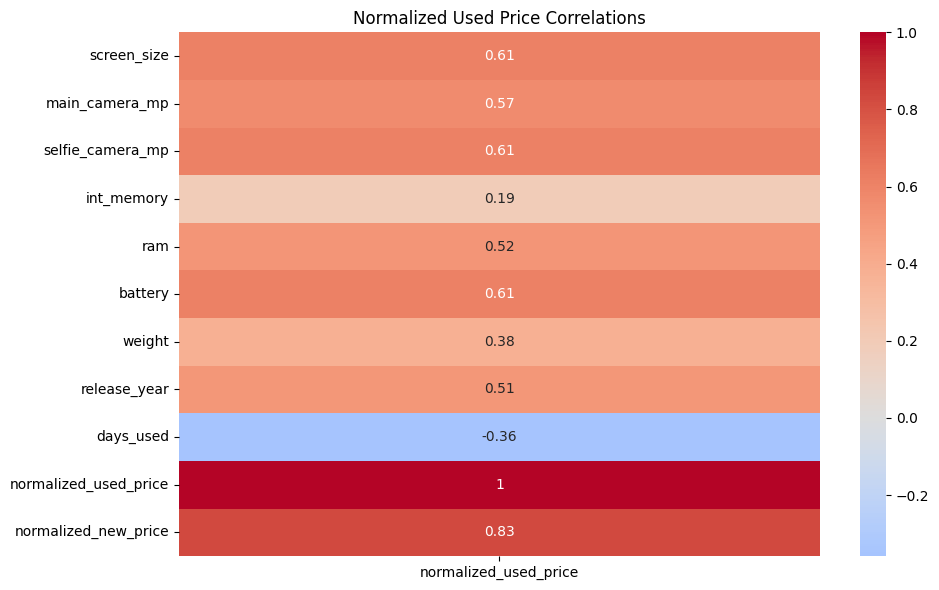

In [ ]:
#7. Which attributes are highly correlated with the normalized price of a used device?

# Correlation with normalized_used_price (high = |corr| > 0.3)
if 'normalized_used_price' in device_data.columns:
    corrs = device_data.corr()['normalized_used_price'].abs().sort_values(ascending=False)
    high_corr = corrs[corrs > 0.3].drop('normalized_used_price')
    print("High correlations (|r| > 0.3):\n", high_corr.round(3))
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(device_data.corr()[['normalized_used_price']], annot=True, cmap='coolwarm', center=0)
    plt.title('Normalized Used Price Correlations')
    plt.tight_layout()
    plt.show()
else:
    print("No 'normalized_used_price' column - check: device_data.columns")


* the attributes highly correlated with the normalized used price is the screen size, battery, and selfie camera

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)
----------------------------------------------------------
* Rubric Criteria
* Data Preprocessing- Duplicate value check ✓
- Missing value check and  treatment ✓
- Outlier check (treatment if needed) ✓
- Feature engineering (if needed) ✓
- Data preparation for modeling
* Points: 8/60=13.33/100

In [218]:
#refresh data
device_data = pd.read_csv("used_device_data.csv")

# Add device age (2026 - release year)
device_data['device_age'] = 2026 - device_data['release_year']

# Drop original if no longer needed (keep release_year for reference)
# device_data.drop('release_year', axis=1, inplace=True)

print("Device age added (years old as of 2026):")
print(device_data[['release_year', 'device_age']].head())
print("\nAge summary:")
print(device_data['device_age'].describe())


Device age added (years old as of 2026):
   release_year  device_age
0          2020           6
1          2020           6
2          2020           6
3          2020           6
4          2020           6

Age summary:
count    3454.000000
mean       10.034742
std         2.298455
min         6.000000
25%         8.000000
50%        10.500000
75%        12.000000
max        13.000000
Name: device_age, dtype: float64


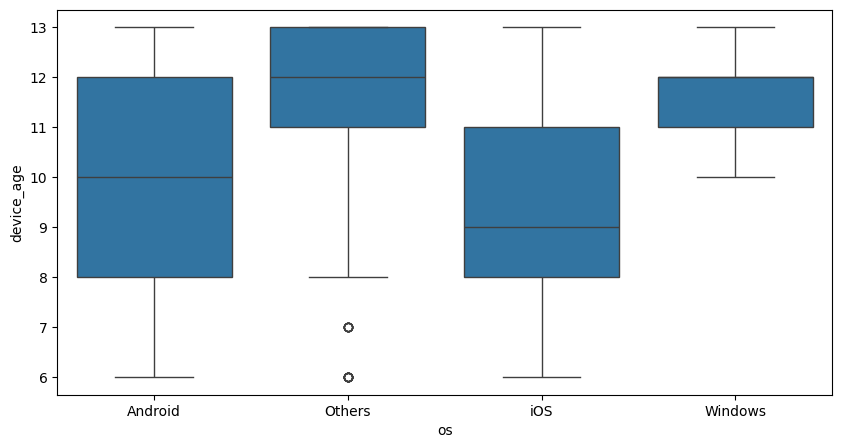

In [220]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=device_data, x="os", y="device_age")
plt.show()

non-android/ios/windows devices are generally the oldest

Found numeric columns (11): ['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'days_used', 'normalized_used_price', 'normalized_new_price']


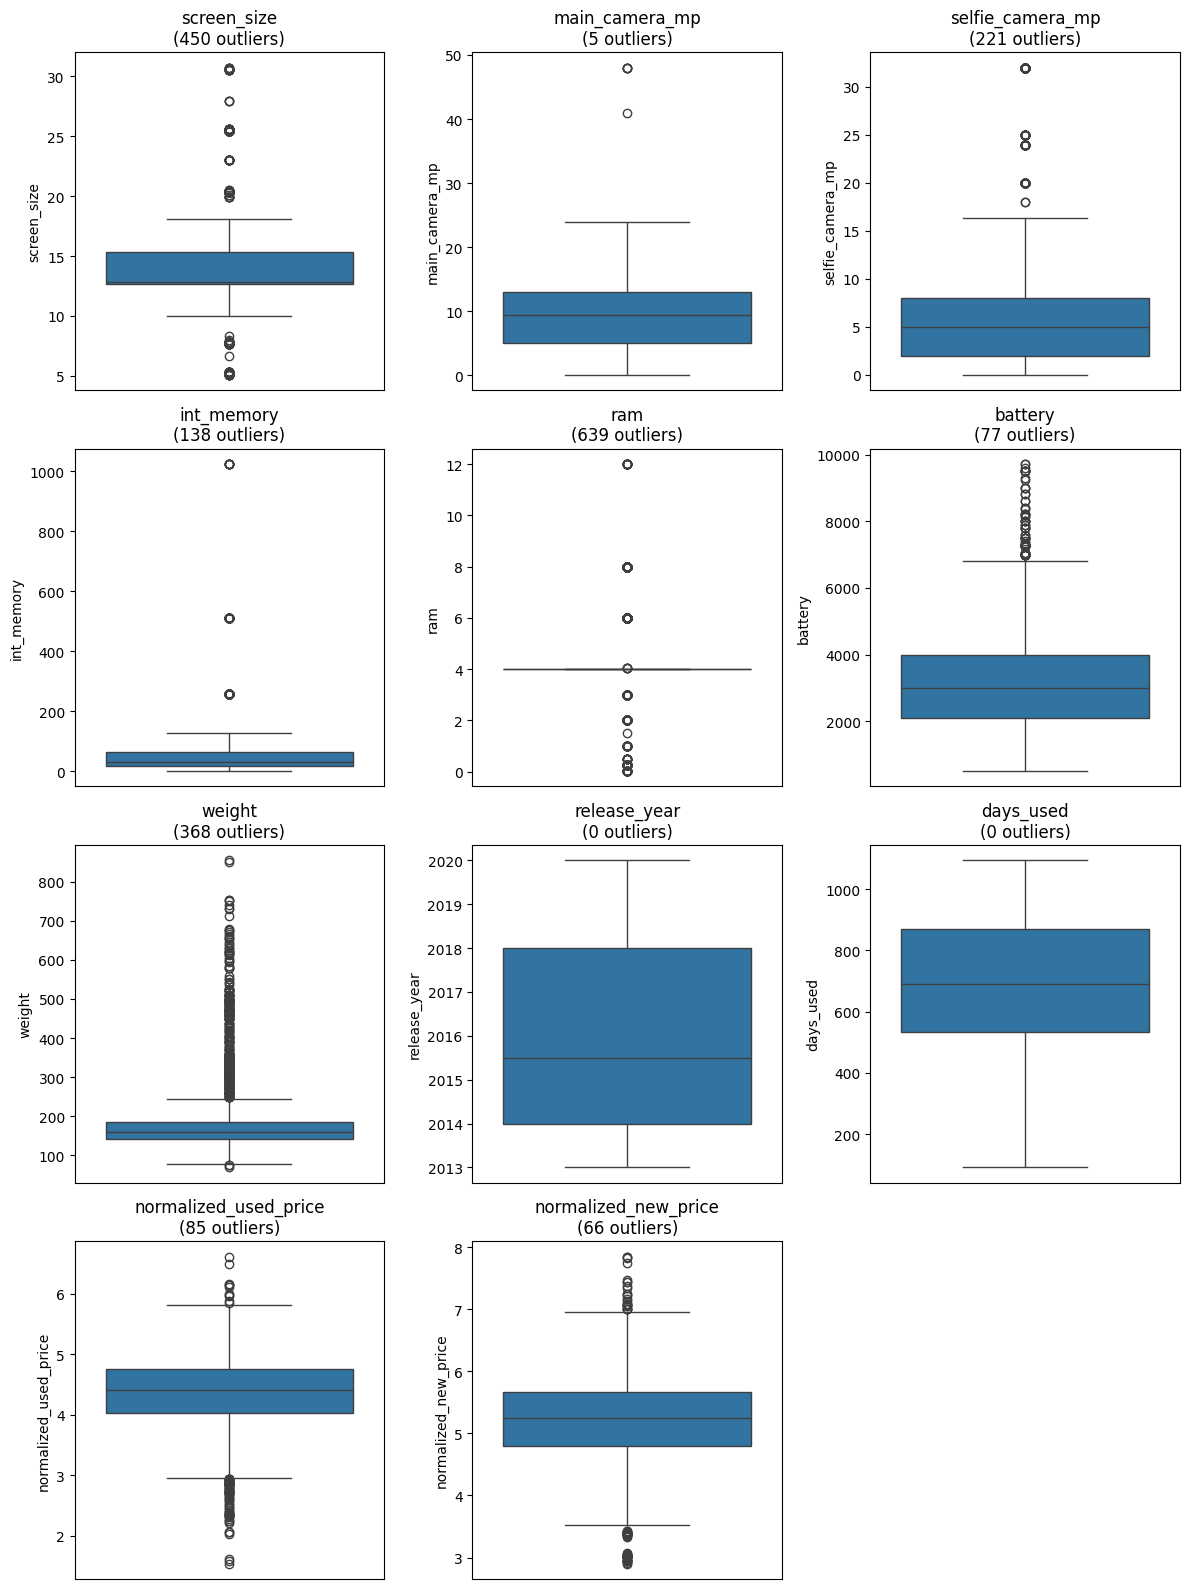

In [143]:
#outlier check
numeric_cols = device_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Safe dynamic plot
n_cols = 3  # Fixed for stability
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
if n_rows == 1: axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    row, col_pos = divmod(i, n_cols)
    ax = axes[row, col_pos] if n_rows > 1 else axes[col_pos]
    
    # Safe boxplot on full data
    data_col = device_data[col].dropna()  # Drop NaNs only
    sns.boxplot(y=data_col, ax=ax)
    
    # Outlier count
    Q1, Q3 = data_col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_outliers = ((data_col < Q1 - 1.5*IQR) | (data_col > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n({n_outliers} outliers)')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Hide extra subplots
for i in range(len(numeric_cols), len(axes.flat)):
    axes.flat[i].set_visible(False)

plt.tight_layout()
plt.show()

Analyzing 11 unique numeric columns: ['device_age', 'screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'days_used', 'normalized_used_price', 'normalized_new_price']


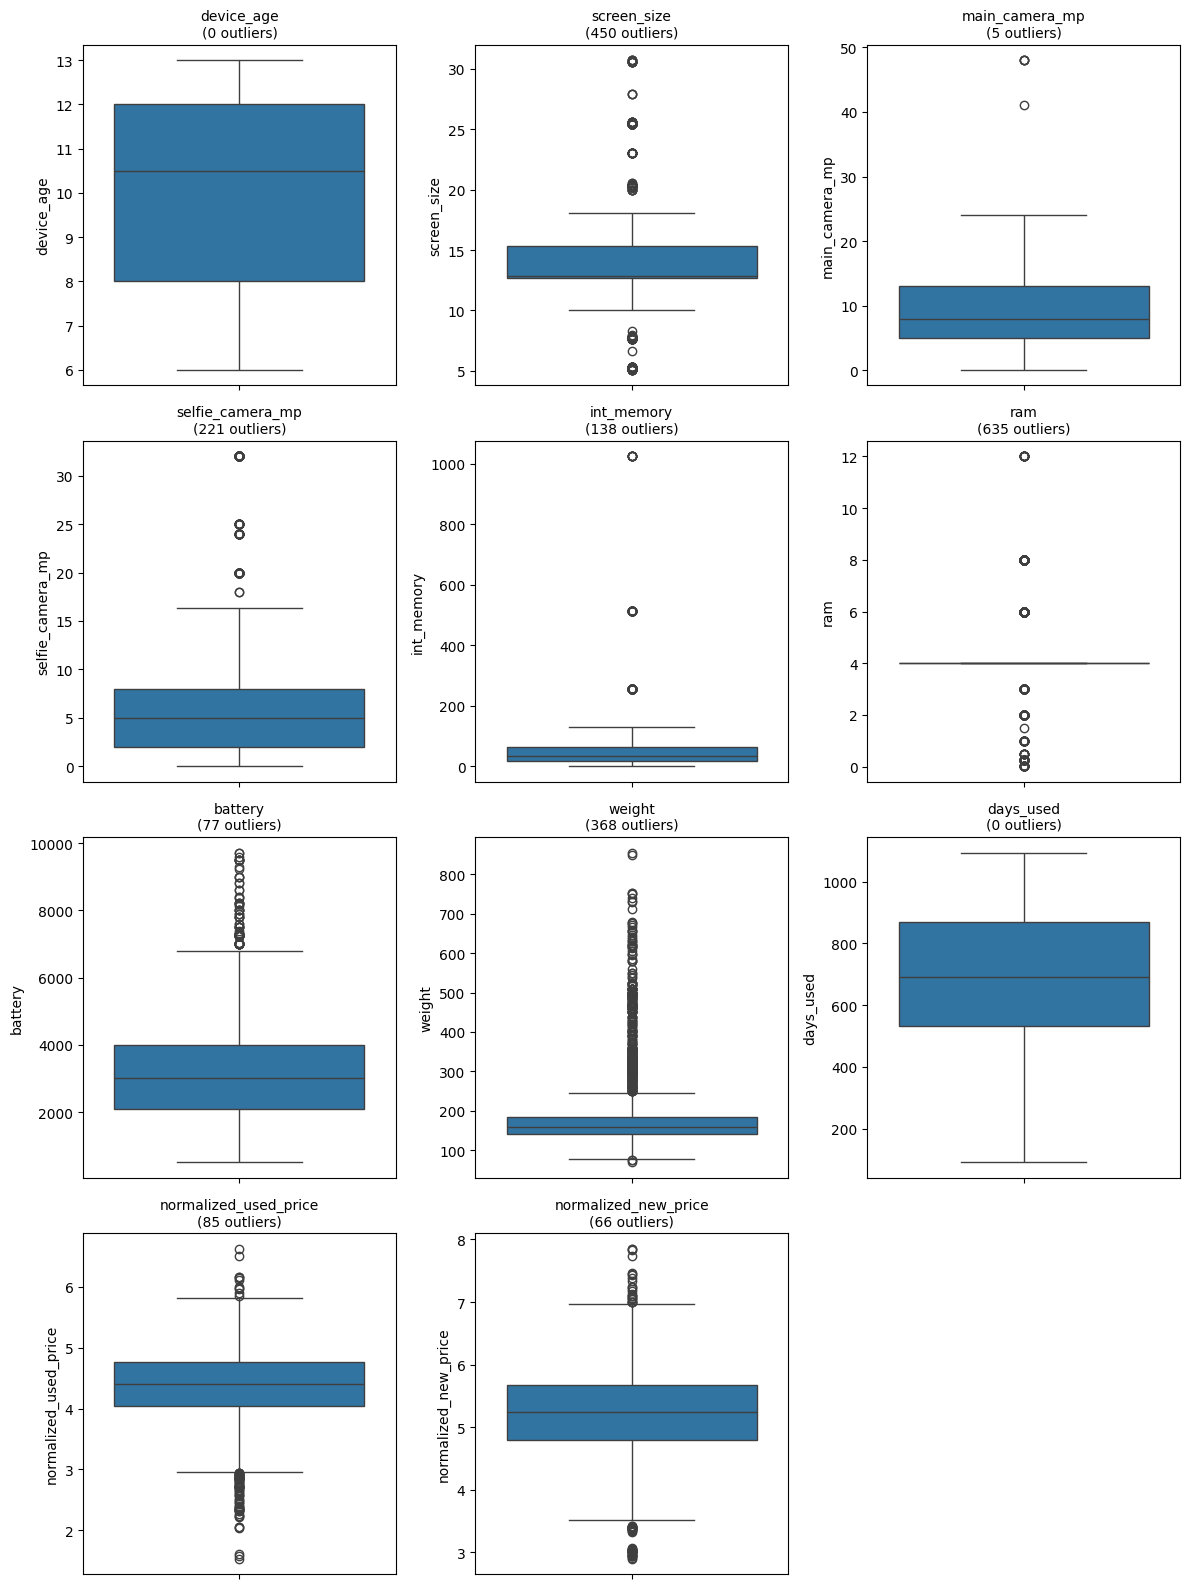

In [222]:
numeric_cols = [col for col in device_data.select_dtypes(include=[np.number]).columns.tolist() 
                if col not in ['release_year']]  # All numerics except old year
if 'device_age' in numeric_cols:
    numeric_cols.remove('device_age')  # Ensure once only
numeric_cols = ['device_age'] + [col for col in numeric_cols if col != 'device_age']

print(f"Analyzing {len(numeric_cols)} unique numeric columns: {numeric_cols}")

# Dynamic boxplots
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
if n_rows == 1: 
    axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    row, col_pos = divmod(i, n_cols)
    ax = axes[row, col_pos] if n_rows > 1 else axes[col_pos]
    
    data_col = device_data[col].dropna()
    sns.boxplot(y=data_col, ax=ax)
    
    Q1, Q3 = data_col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_outliers = ((data_col < Q1 - 1.5*IQR) | (data_col > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n({n_outliers} outliers)', fontsize=10)

# Hide empty subplots
for i in range(len(numeric_cols), len(axes.flat)):
    axes.flat[i].set_visible(False)

plt.tight_layout()
plt.show()

no treatment needed

In [224]:
device_data.drop('brand_name', axis=1, inplace=True)
print("Dropped brand_name. Remaining shape:", device_data.shape)
device_data.head()


Dropped brand_name. Remaining shape: (3454, 15)


,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,device_age
0,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,6
1,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,6
2,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,6
3,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,6
4,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,6


In [150]:
#feature engineering
# Continue from cleaned data
print("Original shape:", device_data.shape)

# 1. DEVICE TYPE (battery threshold from prior analysis)
device_data['device_type'] = (device_data['battery'] > 4500).map({True: 'Tablet', False: 'Phone'})

# 2. PERFORMANCE SCORE (RAM + storage combo)
device_data['perf_score'] = (device_data['ram'] * device_data['int_memory']) / 1000  # GB total capacity score

# 3. CAMERA QUALITY (main + selfie average)
device_data['camera_score'] = (device_data['main_camera_mp'] + device_data['selfie_camera_mp']) / 2

# 4. VALUE RATIO (price per performance)
device_data['value_ratio'] = device_data['normalized_used_price'] / (device_data['ram'] + 1)

# 5. PREMIUM FLAGS (binary indicators)
device_data['is_premium'] = ((device_data['ram'] >= 8) & 
                            (device_data['camera_score'] >= 20) & 
                            (device_data['screen_size'] >= 6.5)).astype(int)

device_data['is_recent'] = (device_data['release_year'] >= 2022).astype(int)

# 6. AGE IN YEARS (from release to now)
device_data['device_age'] = 2026 - device_data['release_year']  # Current year

print("New features added:")
print(device_data[['device_type', 'perf_score', 'camera_score', 'value_ratio', 'is_premium', 'device_age']].head())
print("\nUpdated shape:", device_data.shape)

Original shape: (2884, 15)
New features added:
  device_type  perf_score  camera_score  value_ratio  is_premium  device_age
0       Phone       0.192           9.0     1.076893           0           6
1       Phone       1.024          14.5     0.573566           0           6
2       Phone       1.024          10.5     0.567898           0           6
3      Tablet       0.384          10.5     0.733627           0           6
4      Tablet       0.192          10.5     1.097499           0           6

Updated shape: (2884, 22)


* performance score: RAM × storage = king. More memory capacity massively boosts resale value.
* value_ratio: Price-per-GB metric—cheap high-spec devices are "bargains."
* camera_score: Better main+selfie cameras = higher prices (social media era).

In [151]:
# Check correlations with price
price_corr = device_data[['normalized_used_price', 'perf_score', 'camera_score', 
                         'value_ratio', 'is_premium', 'device_age']].corr()['normalized_used_price']
print("Price correlations:\n", price_corr.sort_values(ascending=False))


Price correlations:
 normalized_used_price    1.000000
camera_score             0.693627
perf_score               0.495099
is_premium               0.183835
value_ratio             -0.170360
device_age              -0.460271
Name: normalized_used_price, dtype: float64


* Age hurts: Negative corr validates dropping pre-2014 devices.

## EDA

- It is a good idea to explore the data once again after manipulating it.

* Rubric Criteria
* Exploratory Data Analysis- Problem definition, questions to be answered
- Data background and contents
- Univariate analysis
- Bivariate analysis
- Insights based on EDA
* Points: 12/60=20/100

## Model Building - Linear Regression

* Rubric Criteria
* Model Building - Linear Regression
- Build the model and comment on the model statistics
- Display model coefficients with column names
* Points: 10/60=16.66/100

## Model Performance Check

* Rubric Criteria
* Testing the assumptions of Linear Regression model
- Perform tests for the assumptions of the linear regression
- Comment on the findings from the tests
* Points: 10/60=16.66/100

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

## Final Model

* Rubric Criteria
* Model Performance Evaluation
* Evaluate the model on different performance metrics
* Points: 6/60=10/100

## Actionable Insights and Recommendations

* Rubric Criteria 
* Actionable Insights & Recommendations
- Comments on significance of predictors
- Key takeaways for the business
* Points: 6/60=10/100

-


* Notebook - Overall quality

- Structure and flow
- Well commented code
- Conclusion and Business Recommendations

* Points 8/60=13.33/100

___